---
numbering: false
---

# 6.1. Linear Transformations

## Overview

The big concept introduced in [Chapter 5.3](../05_matrices/03-rank-and-column-space.ipynb) was the **rank** of a matrix, $\text{rank}(A)$, which is the number of linearly independent columns of a matrix. The rank of a matrix told us the dimension of its column space, $\text{colsp}(A)$, which is the set of all vectors that can be created with linear combinations of $A$'s columns. 

The ideas of rank, column space, and linear independence are all closely related, and also all apply for matrices of any shape – wide, tall, or square. This is good, because data from the real world is rarely square: we usually have many more observations ($n$) than features ($d$).

The big idea in Chapters 6.1 and 6.2 is that of the **inverse** of a matrix, $A^{-1}$, which **only applies to square matrices**. But, inverses and square matrices can still be useful for our rectangular matrices with real data, since the matrix $A^TA$ is square, no matter the shape of $A$. And, as we discussed in [Chapter 5.3](../05_matrices/03-rank-and-column-space.ipynb) and you're seeing in Homework 6, the matrix $A^TA$ has close ties to the correlations between the columns of $A$, which you already know has some connection to linear regression.

---

## Linear Transformations

But first, I want us to think about matrix-vector multiplication as something more than just number crunching.

In [Chapter 5.3](../05_matrices/03-rank-and-column-space.ipynb), the running example was the matrix

$$A = \begin{bmatrix} 5 & 3 & 2 \\ 0 & -1 & 1 \\ 3 & 4 & -1 \\ 6 & 2 & 4 \\ 1 & 0 & 1 \end{bmatrix}$$

To multiply $A$ by a vector on the right, that vector must be in $\mathbb{R}^3$, and the result will be a vector in $\mathbb{R}^5$.

Put another way, if we consider the function $T(\vec x) = A \vec x$, $T$ maps elements of $\mathbb{R}^3$ to elements of $\mathbb{R}^5$, i.e.

$$T: \mathbb{R}^3 \to \mathbb{R}^5$$

I've chosen the letter $T$ to denote that $T$ is a **linear transformation**.

:::{note} Definition: Linear Transformation
A function $T: \mathbb{R}^d \to \mathbb{R}^n$ is a **linear transformation** if for any $\vec x, \vec y \in \mathbb{R}^d$ and any $c \in \mathbb{R}$,

1. $T(\vec x + \vec y) = T(\vec x) + T(\vec y)$
2. $T(c \vec x) = c T(\vec x)$

$\mathbb{R}^d$ is the **domain** of $T$, and $\mathbb{R}^n$ is the **codomain** of $T$.
:::

Every linear transformation is of the form $T(\vec x) = A \vec x$. For our purposes, linear transformations and matrix-vector multiplication are the same thing, though in general linear transformations are a more abstract concept (just like how vector spaces can be made up of functions, for example).

For example, the function

$$f(\vec x) = f\left( \begin{bmatrix} x_1 \\ x_2 \end{bmatrix} \right) = \begin{bmatrix} 2x_1 + 3x_2 \\ x_1 \\ x_2 \end{bmatrix}$$

is a linear transformation from $\mathbb{R}^2$ to $\mathbb{R}^3$, and is equivalent to

$$f(\vec x) = \begin{bmatrix} 2x_1 + 3x_2 \\ x_1 \\ x_2 \end{bmatrix} = \underbrace{\begin{bmatrix} 2 & 3 \\ 1 & 0 \\ 0 & 1 \end{bmatrix}}_{\text{matrix}\:  A} \underbrace{\begin{bmatrix} x_1 \\ x_2 \end{bmatrix}}_{\vec x}$$

The function $g(x) = 3x$ is also a linear transformation, from $\mathbb{R}$ to $\mathbb{R}$.

A non-example of a linear transformation is

$$h(\vec x) = \begin{bmatrix} x_1^2 \\ x_2^2 \end{bmatrix}$$

because no matrix multiplied by $\vec x$ will produce $\begin{bmatrix} x_1^2 \\ x_2^2 \end{bmatrix}$.

Another non-example, perhaps surprisingly, is

$$k(x) = -2x + 5$$

This is the equation of a line in $\mathbb{R}^2$, which is linear in some sense, but it's not a linear transformation, since it doesn't satisfy the two properties of linearity. For $k(x)$ to be a linear transformation, we'd need

$$k(cx) = ck(x)$$

for any $c, x \in \mathbb{R}$. But, if we consider $c = 3$ and $x = 1$ as an example, we get

$$k(cx) = k(3 \cdot 1) = k(3) = -2 \cdot 3 + 5 = -1 \\ ck(x) = 3 k(1) = 3 (-2 \cdot 1 + 5) = 3(3) = 9$$

which are not equal. $k(x) = -2x + 5$ is an example of an **affine transformation**, which in general is any function $f: \mathbb{R}^d \to \mathbb{R}^n$ that can be written as $f(\vec x) = A \vec x + \vec b$, where $A$ is an $n \times d$ matrix and $\vec b \in \mathbb{R}^n$.

:::{tip} Activity 1
:class: dropdown

**Activity 1.1**

True or false: if $T$ is a linear transformation, then $T(\vec 0) = \vec 0$.

**Activity 1.2**

For each of the following functions, determine whether it is a linear transformation. If it is, write it in the form $T(\vec x) = A \vec x$. If it is not, explain why not.

1. $T(\vec x) = \begin{bmatrix} x_1 + x_2 \\ x_1 - x_2 \end{bmatrix}$
1. $T(\vec x) = \begin{bmatrix} 3 x_3 - x_1 \\ x_2 + 2 x_3 \\ 5x_1 + 7x_2 \end{bmatrix}$
1. $T(\vec x) = \begin{bmatrix} 3x_3 - 5 \\ x_2 + 2 x_3 \\ 5x_1 + 7x_2 \end{bmatrix}$
1. $T(\vec x) = \vec x + \begin{bmatrix} 1 \\ 2 \end{bmatrix}$
1. $T$ takes $\vec x$, multiplies the first component by 2 and second component by 3, and returns the difference between the two, as a scalar.

:::{seealso} Solutions
:class: dropdown

**Activity 1.1**

True or false: if $T$ is a linear transformation, then $T(\vec 0) = \vec 0$.

True. Since $T$ is a linear transformation, we have

$$T(c \vec x) = c T(\vec x)$$

for any $c \in \mathbb{R}$ and $\vec x \in \mathbb{R}^d$. Plugging in $c = 0$, we get

$$T(0 \vec x) = 0 T(\vec x) \implies T(\vec 0) = \vec 0$$

**Activity 1.2**

1. $T(\vec x) = \begin{bmatrix} x_1 + x_2 \\ x_1 - x_2 \end{bmatrix}$ **is** a linear transformation.
    $$T(\vec x) = \begin{bmatrix} x_1 + x_2 \\ x_1 - x_2 \end{bmatrix} = \begin{bmatrix} 1 & 1 \\ 1 & -1 \end{bmatrix} \begin{bmatrix} x_1 \\ x_2 \end{bmatrix}$$

2. $T(\vec x) = \begin{bmatrix} 3 x_3 - x_1 \\ x_2 + 2 x_3 \\ 5x_1 + 7x_2 \end{bmatrix}$ **is** a linear transformation.
    $$T(\vec x) = \begin{bmatrix} 3 x_3 - x_1 \\ x_2 + 2 x_3 \\ 5x_1 + 7x_2 \end{bmatrix} = \begin{bmatrix} -1 & 0 & 3 \\ 0 & 1 & 2 \\ 5 & 7 & 0 \end{bmatrix} \begin{bmatrix} x_1 \\ x_2 \\ x_3 \end{bmatrix}$$

3. $T(\vec x) = \begin{bmatrix} 3x_3 - 5 \\ x_2 + 2 x_3 \\ 5x_1 + 7x_2 \end{bmatrix}$ **is not** a linear transformation. Notice the constant term of $-5$ in the first component! This is instead an affine transformation.

4. $T(\vec x) = \vec x + \begin{bmatrix} 1 \\ 2 \end{bmatrix}$ is **not** a linear transformation once again; it's an affine transformation. If you don't believe that it's not a linear transformation, plug in both $\begin{bmatrix} 1 \\ 1 \end{bmatrix}$ and $\begin{bmatrix} 2 \\ 2 \end{bmatrix}$; if $T$ were a linear transformation, the latter output would be exactly double the former output.

5. This description tells us that $T(\vec x) = 2x_1 - 3x_2$, and this **is** a perfectly valid linear transformation, from $\mathbb{R}^2$ to $\mathbb{R}$.
    $$T(\vec x) = \begin{bmatrix} 2 & -3 \end{bmatrix} \begin{bmatrix} x_1 \\ x_2 \end{bmatrix}$$
:::

---

## Linear Transformations from $\mathbb{R}^n$ to $\mathbb{R}^n$

While linear transformations exist from $\mathbb{R}^2$ to $\mathbb{R}^5$ or $\mathbb{R}^{99}$ to $\mathbb{R}^4$, it's in some ways easiest to think about linear transformations with the same domain and codomain, i.e. transformations of the form $T: \mathbb{R}^n \to \mathbb{R}^n$. This will allow us to explore how transformations stretch, rotate, and reflect vectors in the same space. Linear transformations with the same domain ($\mathbb{R}^n$) and codomain ($\mathbb{R}^n$) are represented by $n \times n$ matrices, which gives us a useful setting to think about the invertibility of square matrices, beyond just looking at a bunch of numbers.

To start, let's consider the linear transformation defined by the matrix

$$A = \begin{bmatrix} 2 & 0 \\ 0 & -1/3 \end{bmatrix}$$

What happens to a vector in $\mathbb{R}^2$ when we multiply it by $A$? Let's visualize the effect of $A$ on several vectors in $\mathbb{R}^2$.

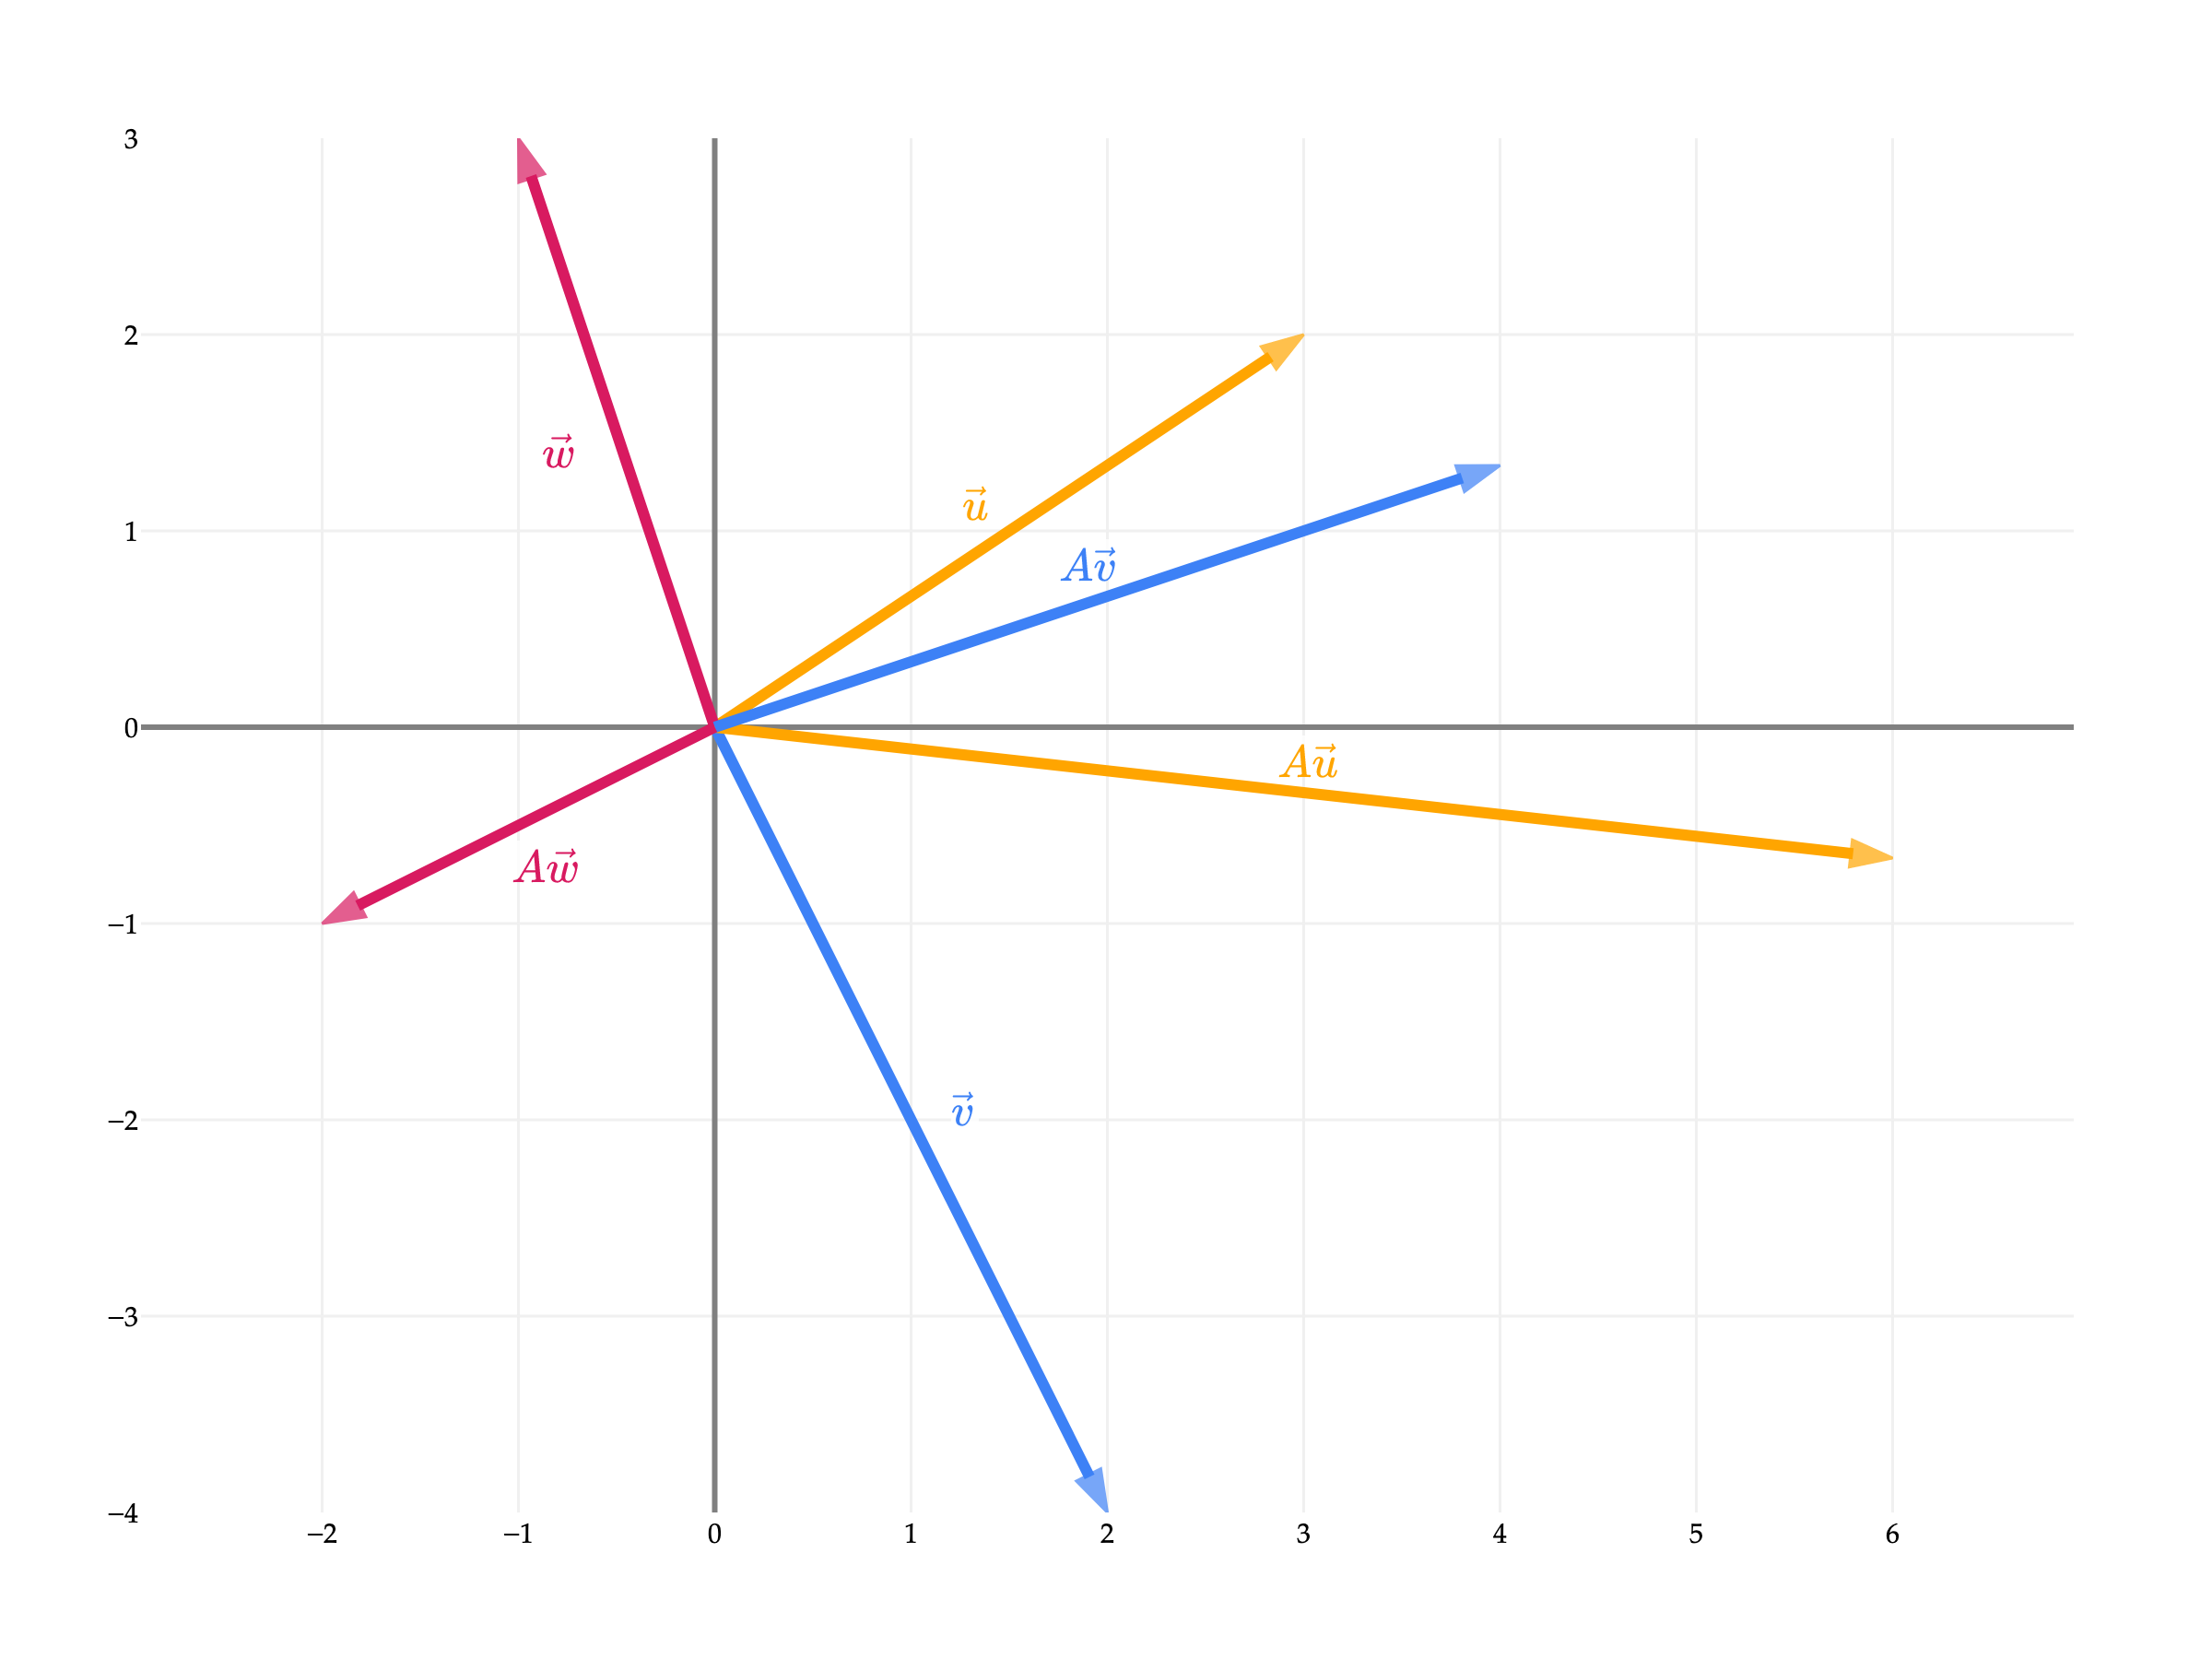

In [51]:
from utils import plot_vectors
import numpy as np

A = np.array([[2, 0], [0, - 1 / 3]])
u = np.array([3, 2])
v = np.array([2, -4])
w = np.array([-1, 3])

Au = A @ u
Av = A @ v
Aw = A @ w

fig = plot_vectors(
    [
        (tuple(u), 'orange', r'$\vec u$'),
        (tuple(v), '#3d81f6', r'$\vec v$'),
        (tuple(w), '#d81a60', r'$\vec w$'),
        (tuple(Au), 'orange', r'$A \vec u$'),
        (tuple(Av), '#3d81f6', r'$A \vec v$'),
        (tuple(Aw), '#d81a60', r'$A \vec w$')
    ],
    vdeltay=0.2
)

# Fix aspect ratio: set both axes to be equal using 'constrain'
fig.update_layout(
    xaxis=dict(range=[-2, 6], dtick=1),
    yaxis=dict(scaleanchor="x", range=[-4, 3], dtick=1)
)

fig.show(scale=3, renderer='png')

$A$ scales, or stretches, the input space by a factor of $2$ in the $x$-direction and a factor of $-1/3$ in the $y$-direction.

### Scaling

Another way of visualizing $A$ is to think about how it transforms the two standard basis vectors of $\mathbb{R}^2$, which are $${\color{#3d81f6}{\vec u_x = \begin{bmatrix} 1 \\ 0 \end{bmatrix}}}, \quad \color{#3d81f6}{\vec u_y = \begin{bmatrix} 0 \\ 1 \end{bmatrix}}$$ (In the past I've called these $\vec e_1$ and $\vec e_2$, but I'll use $\color{#3d81f6}{\vec u_x}$ and $\color{#3d81f6}{\vec u_y}$ here since I'll also use $E$ to represent a matrix shortly.)

Note that $\color{orange}{A \vec u_x} = \begin{bmatrix} 2 \\ 0 \end{bmatrix}$ is just the first column of $A$, and similarly $\color{orange}{A \vec u_y} = \begin{bmatrix} 0 \\ -1/3 \end{bmatrix}$ is the second column of $A$.

$$A = \begin{bmatrix} 2 & 0 \\ 0 & -1/3 \end{bmatrix}$$

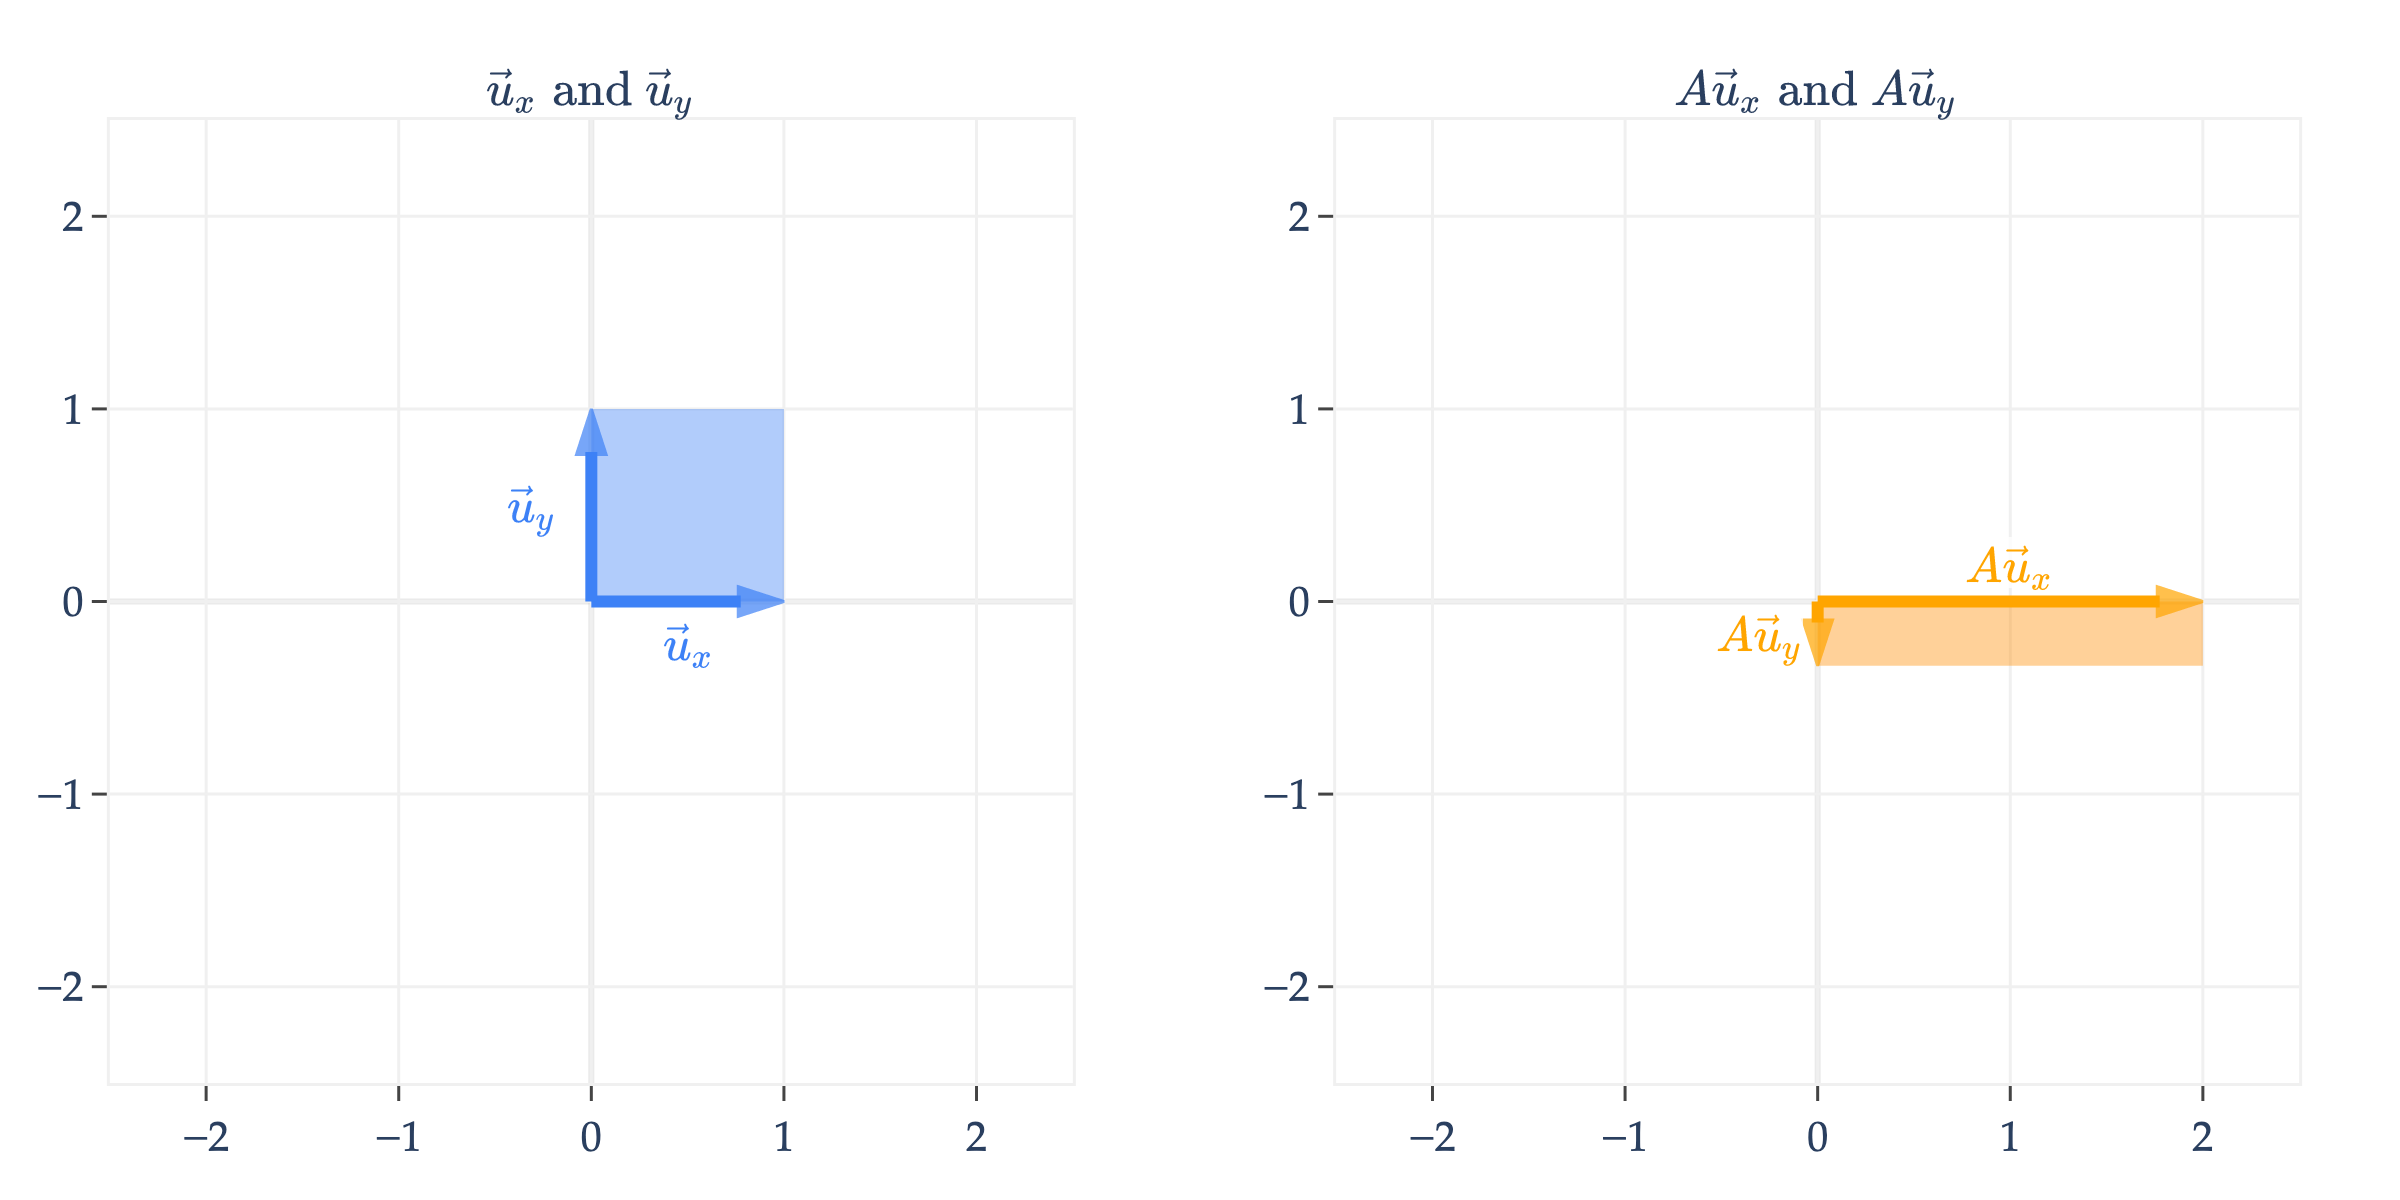

In [3]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from utils import plot_vectors

def plot_unit_square_and_transform(S, name="Matrix", vdeltax=-0.3, vdeltay=0.2, return_fig=False):
    # Vertices of the unit square
    square = np.array([
        [0, 0],  # A
        [1, 0],  # B
        [1, 1],  # C
        [0, 1],  # D
        [0, 0]   # A (to close the square)
    ])
    # Transformed square
    square_trans = (S @ square.T).T

    # Create subplot figure
    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=(r"$$\vec u_x \text{  and } \vec u_y$$", fr"$${name}" + r"\vec u_x \text{  and }" + fr"{name} \vec u_y$$"),
        horizontal_spacing=0.08
    )

    # Common axis settings
    axis_style = dict(
        showgrid=True,
        gridcolor="#f0f0f0",
        zeroline=False,  # We'll add our own zero lines
        showline=True,
        linecolor="#f0f0f0",
        mirror=True,
        ticks="outside",
        showticklabels=True,
        tickfont=dict(family="Palatino, serif", size=14),
    )

    # Set axis ranges to [-2.5, 2.5] for both subplots
    for i in [1, 2]:
        fig.update_xaxes(
            range=[-2.5, 2.5],
            constrain="domain",
            dtick=1,
            **axis_style,
            row=1, col=i
        )
        fig.update_yaxes(
            range=[-2.5, 2.5],
            scaleanchor=f"x{i}",
            dtick=1,
            **axis_style,
            row=1, col=i
        )

    # --- Draw faint 0 grid lines underneath everything else ---
    for i in [1, 2]:
        # Horizontal y=0
        fig.add_shape(
            type="line",
            x0=-2.5, x1=2.5, y0=0, y1=0,
            line=dict(color="rgba(170,170,170,0.25)", width=2, dash="solid"),
            row=1, col=i,
            layer="below"
        )
        # Vertical x=0
        fig.add_shape(
            type="line",
            x0=0, x1=0, y0=-2.5, y1=2.5,
            line=dict(color="rgba(170,170,170,0.25)", width=2, dash="solid"),
            row=1, col=i,
            layer="below"
        )

    # Plot original unit square (no perimeter, low opacity)
    fig.add_trace(
        go.Scatter(
            x=square[:,0], y=square[:,1],
            fill="toself",
            fillcolor="rgba(61,129,246,0.4)",
            line=dict(color="rgba(0,0,0,0)", width=0),  # No perimeter
            name="Unit Square",
            showlegend=False
        ),
        row=1, col=1
    )

    # Plot transformed square (no perimeter, low opacity)
    fig.add_trace(
        go.Scatter(
            x=square_trans[:,0], y=square_trans[:,1],
            fill="toself",
            fillcolor="rgba(255,140,0,0.4)",
            line=dict(color="rgba(0,0,0,0)", width=0),  # No perimeter
            name="Transformed Square",
            showlegend=False
        ),
        row=1, col=2
    )

    # --- Draw vectors using plot_vectors ---
    # Standard basis vectors
    u_x = np.array([1, 0])
    u_y = np.array([0, 1])
    # Transformed basis vectors
    Su_x = S @ u_x
    Su_y = S @ u_y

    # Left: u_x, u_y in #3d81f6
    left_vecs = [
        (tuple(u_x), '#3d81f6', r'$\vec u_x$'),
        (tuple(u_y), '#3d81f6', r'$\vec u_y$')
    ]
    left_fig = plot_vectors(left_vecs, vdeltay=-0.2)
    # Remove background, axes, and grid from plot_vectors output
    left_fig.update_layout(
        plot_bgcolor="rgba(0,0,0,0)",
        paper_bgcolor="rgba(0,0,0,0)",
        xaxis=dict(visible=False),
        yaxis=dict(visible=False),
        margin=dict(l=0, r=0, t=0, b=0)
    )
    # Add the vector traces to the left subplot
    for trace in left_fig.data:
        fig.add_trace(trace, row=1, col=1)
    # Add the vector annotations to the left subplot
    for ann in left_fig.layout.annotations:
        # Convert Plotly Annotation object to dict safely
        if hasattr(ann, "to_plotly_json"):
            ann_dict = ann.to_plotly_json()
        else:
            ann_dict = dict(ann)
        # Remove keys that are not valid for add_annotation
        ann_dict = {k: v for k, v in ann_dict.items() if k not in {"xref", "yref", "axref", "ayref"}}
        fig.add_annotation(**ann_dict, row=1, col=1)

    # Right: Su_x, Su_y in orange, with correct labels
    right_vecs = [
        (tuple(Su_x), 'orange', rf'${name} \vec u_x$'),
        (tuple(Su_y), 'orange', rf'${name} \vec u_y$')
    ]
    right_fig = plot_vectors(right_vecs, vdeltax=vdeltax, vdeltay=vdeltay)
    right_fig.update_layout(
        plot_bgcolor="rgba(0,0,0,0)",
        paper_bgcolor="rgba(0,0,0,0)",
        xaxis=dict(visible=False),
        yaxis=dict(visible=False),
        margin=dict(l=0, r=0, t=0, b=0)
    )
    for trace in right_fig.data:
        fig.add_trace(trace, row=1, col=2)
    for ann in right_fig.layout.annotations:
        # Convert Plotly Annotation object to dict safely
        if hasattr(ann, "to_plotly_json"):
            ann_dict = ann.to_plotly_json()
        else:
            ann_dict = dict(ann)
        # Remove keys that are not valid for add_annotation
        ann_dict = {k: v for k, v in ann_dict.items() if k not in {"xref", "yref", "axref", "ayref"}}
        fig.add_annotation(**ann_dict, row=1, col=2)

    fig.update_layout(
        font=dict(family="Palatino, serif", size=16),
        plot_bgcolor="white",
        paper_bgcolor="white",
        margin=dict(l=20, r=20, t=40, b=20),
        width=800, height=400,
    )

    if return_fig:
        return fig
    fig.show(renderer='png', scale=3)

# Example usage:
A = np.array([[2, 0], [0, -1/3]])
plot_unit_square_and_transform(A, name="A")

In addition to drawing $\color{#3d81f6}\vec u_x$ and $\color{#3d81f6}\vec u_y$ on the left and their transformed counterparts $\color{orange}A \vec u_x$ and $\color{orange}A \vec u_y$ on the right, I've also shaded in how the **unit square**, which is the square containing $\color{#3d81f6}\vec u_x$ and $\color{#3d81f6}\vec u_y$, gets transformed. Here, it gets stretched from a square to a rectangle.

Remember that any vector $\vec v \in \mathbb{R}^2$ is a linear combination of $\color{#3d81f6}\vec u_x$ and $\color{#3d81f6}\vec u_y$. For instance,

$$\begin{bmatrix} 2 \\ -1 \end{bmatrix} = 2 \begin{bmatrix} 1 \\ 0 \end{bmatrix} - \begin{bmatrix} 0 \\ 1 \end{bmatrix} = \underbrace{2 {\color{#3d81f6}{\vec u_x}} - {\color{#3d81f6}{\vec u_y}}}_{\vec v}$$

So, multiplying $A$ by $\vec v$ is equivalent to multiplying $A$ by a linear combination of $\vec u_x$ and $\vec u_y$.

$$A \begin{bmatrix} 2 \\ -1 \end{bmatrix} = A (2 {\color{#3d81f6}{\vec u_x}} - {\color{#3d81f6}{\vec u_y}}) = 2{\color{orange}{A \vec u_x}} - {\color{orange}{A \vec u_y}}$$

and the result is a linear combination of $\color{orange}{A \vec u_x}$ and $\color{orange}{A \vec u_y}$ with the same coefficients! **If this sounds confusing, just remember that $\color{orange} A{\vec u_x}$ and $\color{orange} A{\vec u_y}$ are just the first and second columns of $A$, respectively.**

So, as we move through the following examples, think of the transformed basis vectors $\color{orange}{A \vec u_x}$ and $\color{orange}{A \vec u_y}$ as a new set of "building blocks" that define the transformed space (which is the column space of $A$).

$A$ is a diagonal matrix, which means it **scales** vectors. Note that **any** vector in $\mathbb{R}^2$ can be transformed by $A$, not just vectors on or within the unit square; I'm just using these two basis vectors to visualize the transformation.

### Rotations and Orthogonal Matrices

What might a non-diagonal matrix do? Let's consider

$$B = \begin{bmatrix} \sqrt{2} / 2 & -\sqrt{2} / 2 \\ \sqrt{2} / 2 & \sqrt{2} / 2 \end{bmatrix}$$

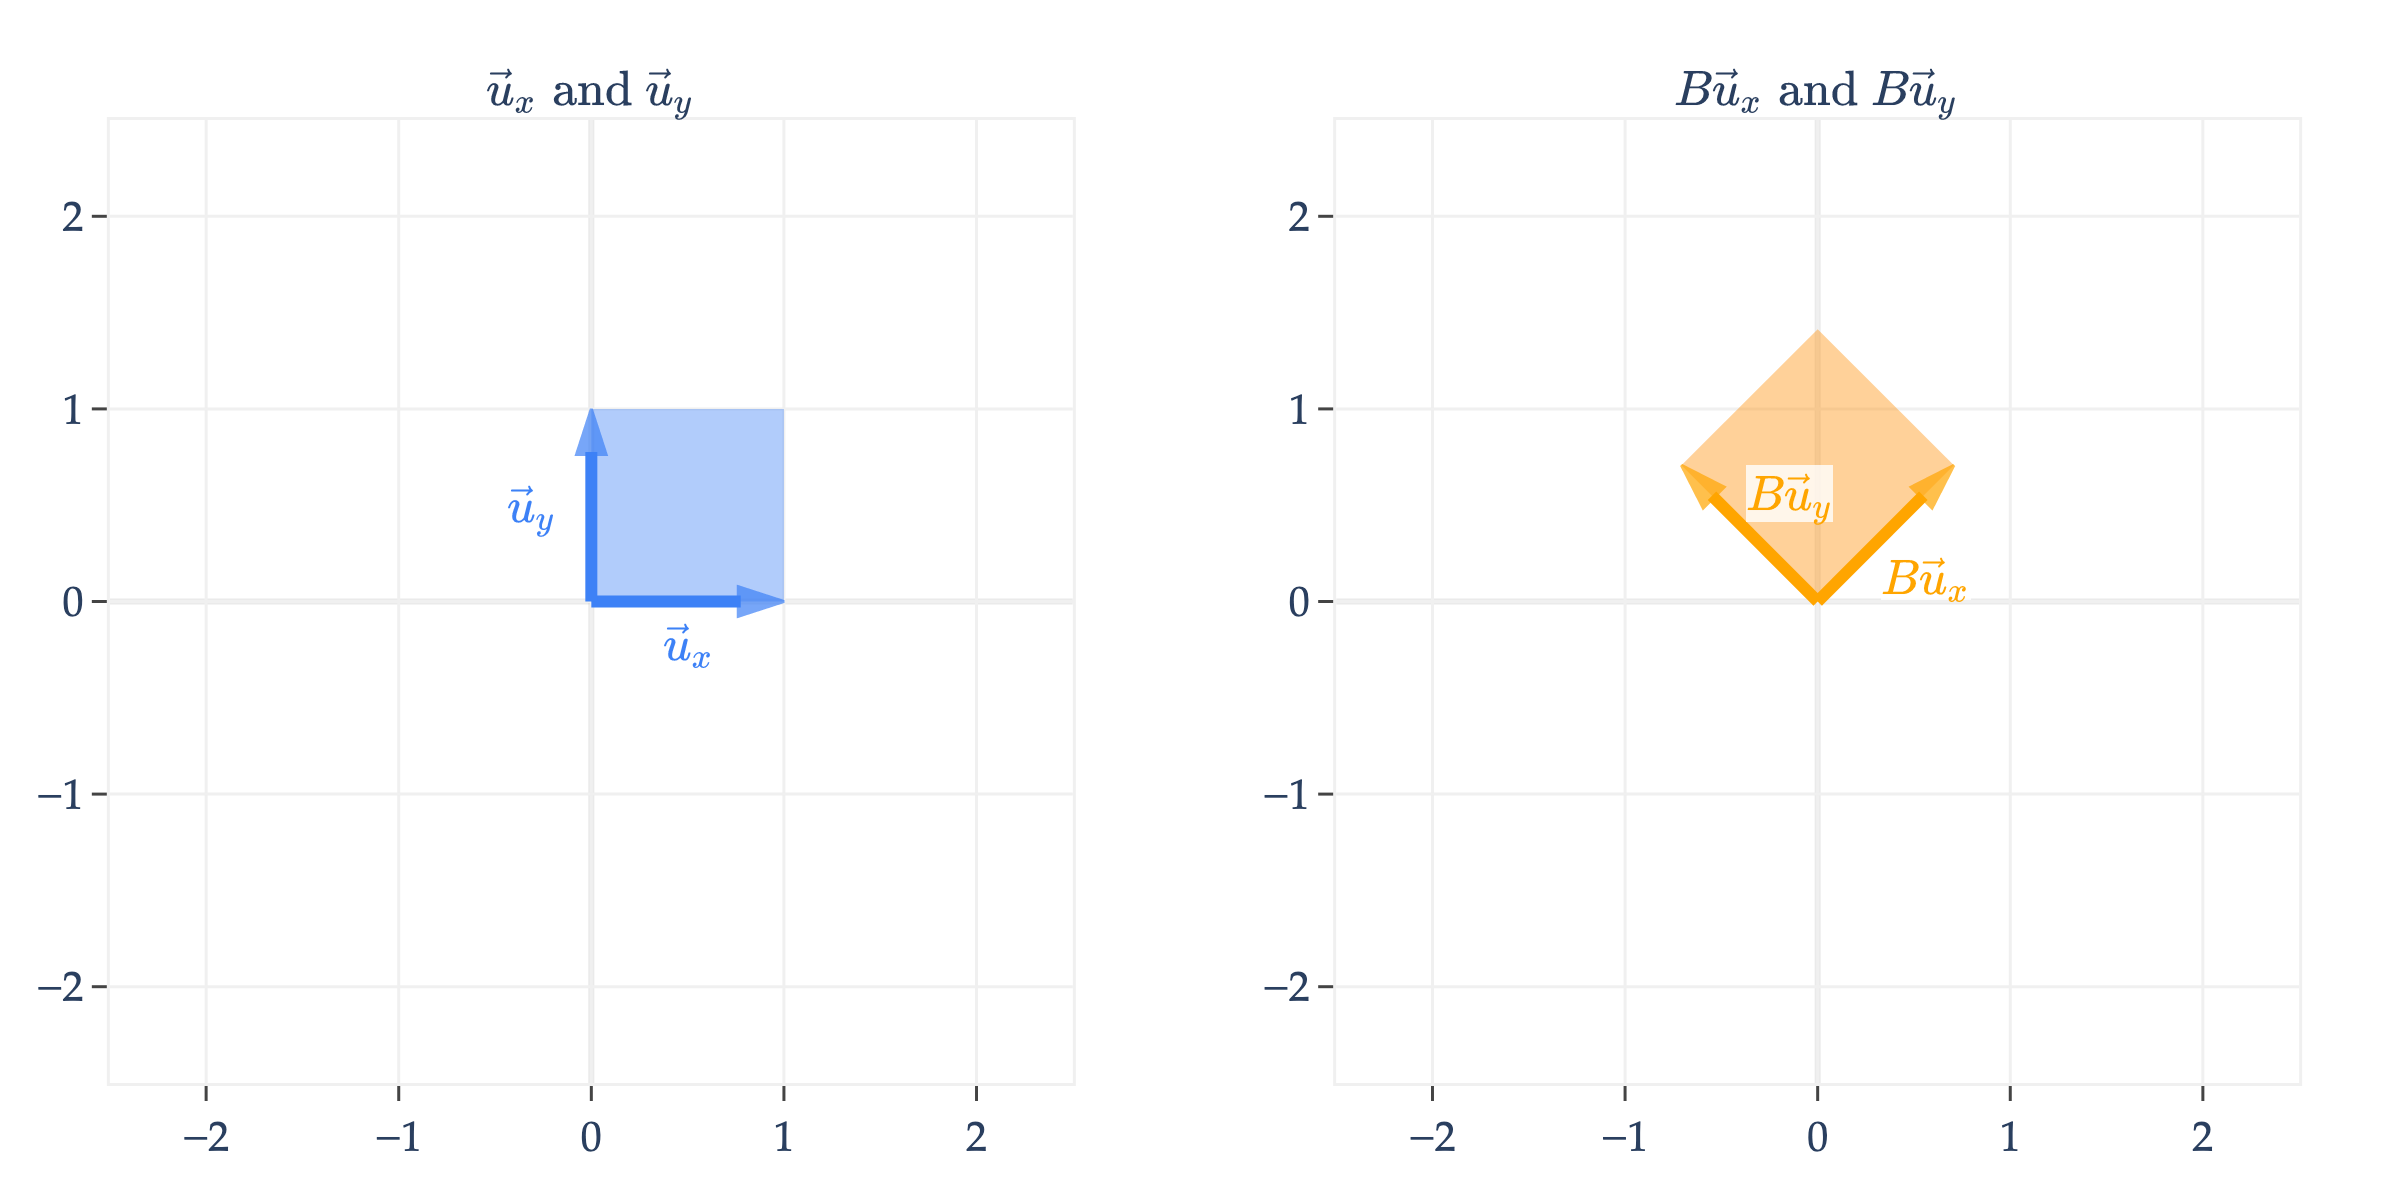

In [4]:
B = np.array([[np.cos(np.pi/4), -np.sin(np.pi/4)], 
              [np.sin(np.pi/4), np.cos(np.pi/4)]])
plot_unit_square_and_transform(B, name="B", vdeltay=-0.3)

Just to continue the previous example, the vector $\begin{bmatrix} 2 \\ -1 \end{bmatrix}$ is transformed into

$$B \begin{bmatrix} 2 \\ -1 \end{bmatrix} = \begin{bmatrix} \sqrt{2} / 2 & -\sqrt{2} / 2 \\ \sqrt{2} / 2 & \sqrt{2} / 2 \end{bmatrix} \begin{bmatrix} 2 \\ -1 \end{bmatrix} = 2 \underbrace{\begin{bmatrix} \sqrt{2} / 2 \\ \sqrt{2} / 2 \end{bmatrix}}_{\color{orange}B \vec u_x} - \underbrace{\begin{bmatrix} -\sqrt{2} / 2 \\ \sqrt{2} / 2 \end{bmatrix}}_{\color{orange} B \vec u_y} = \begin{bmatrix} 3 \sqrt{2} / 2 \\ \sqrt{2} / 2 \end{bmatrix}$$

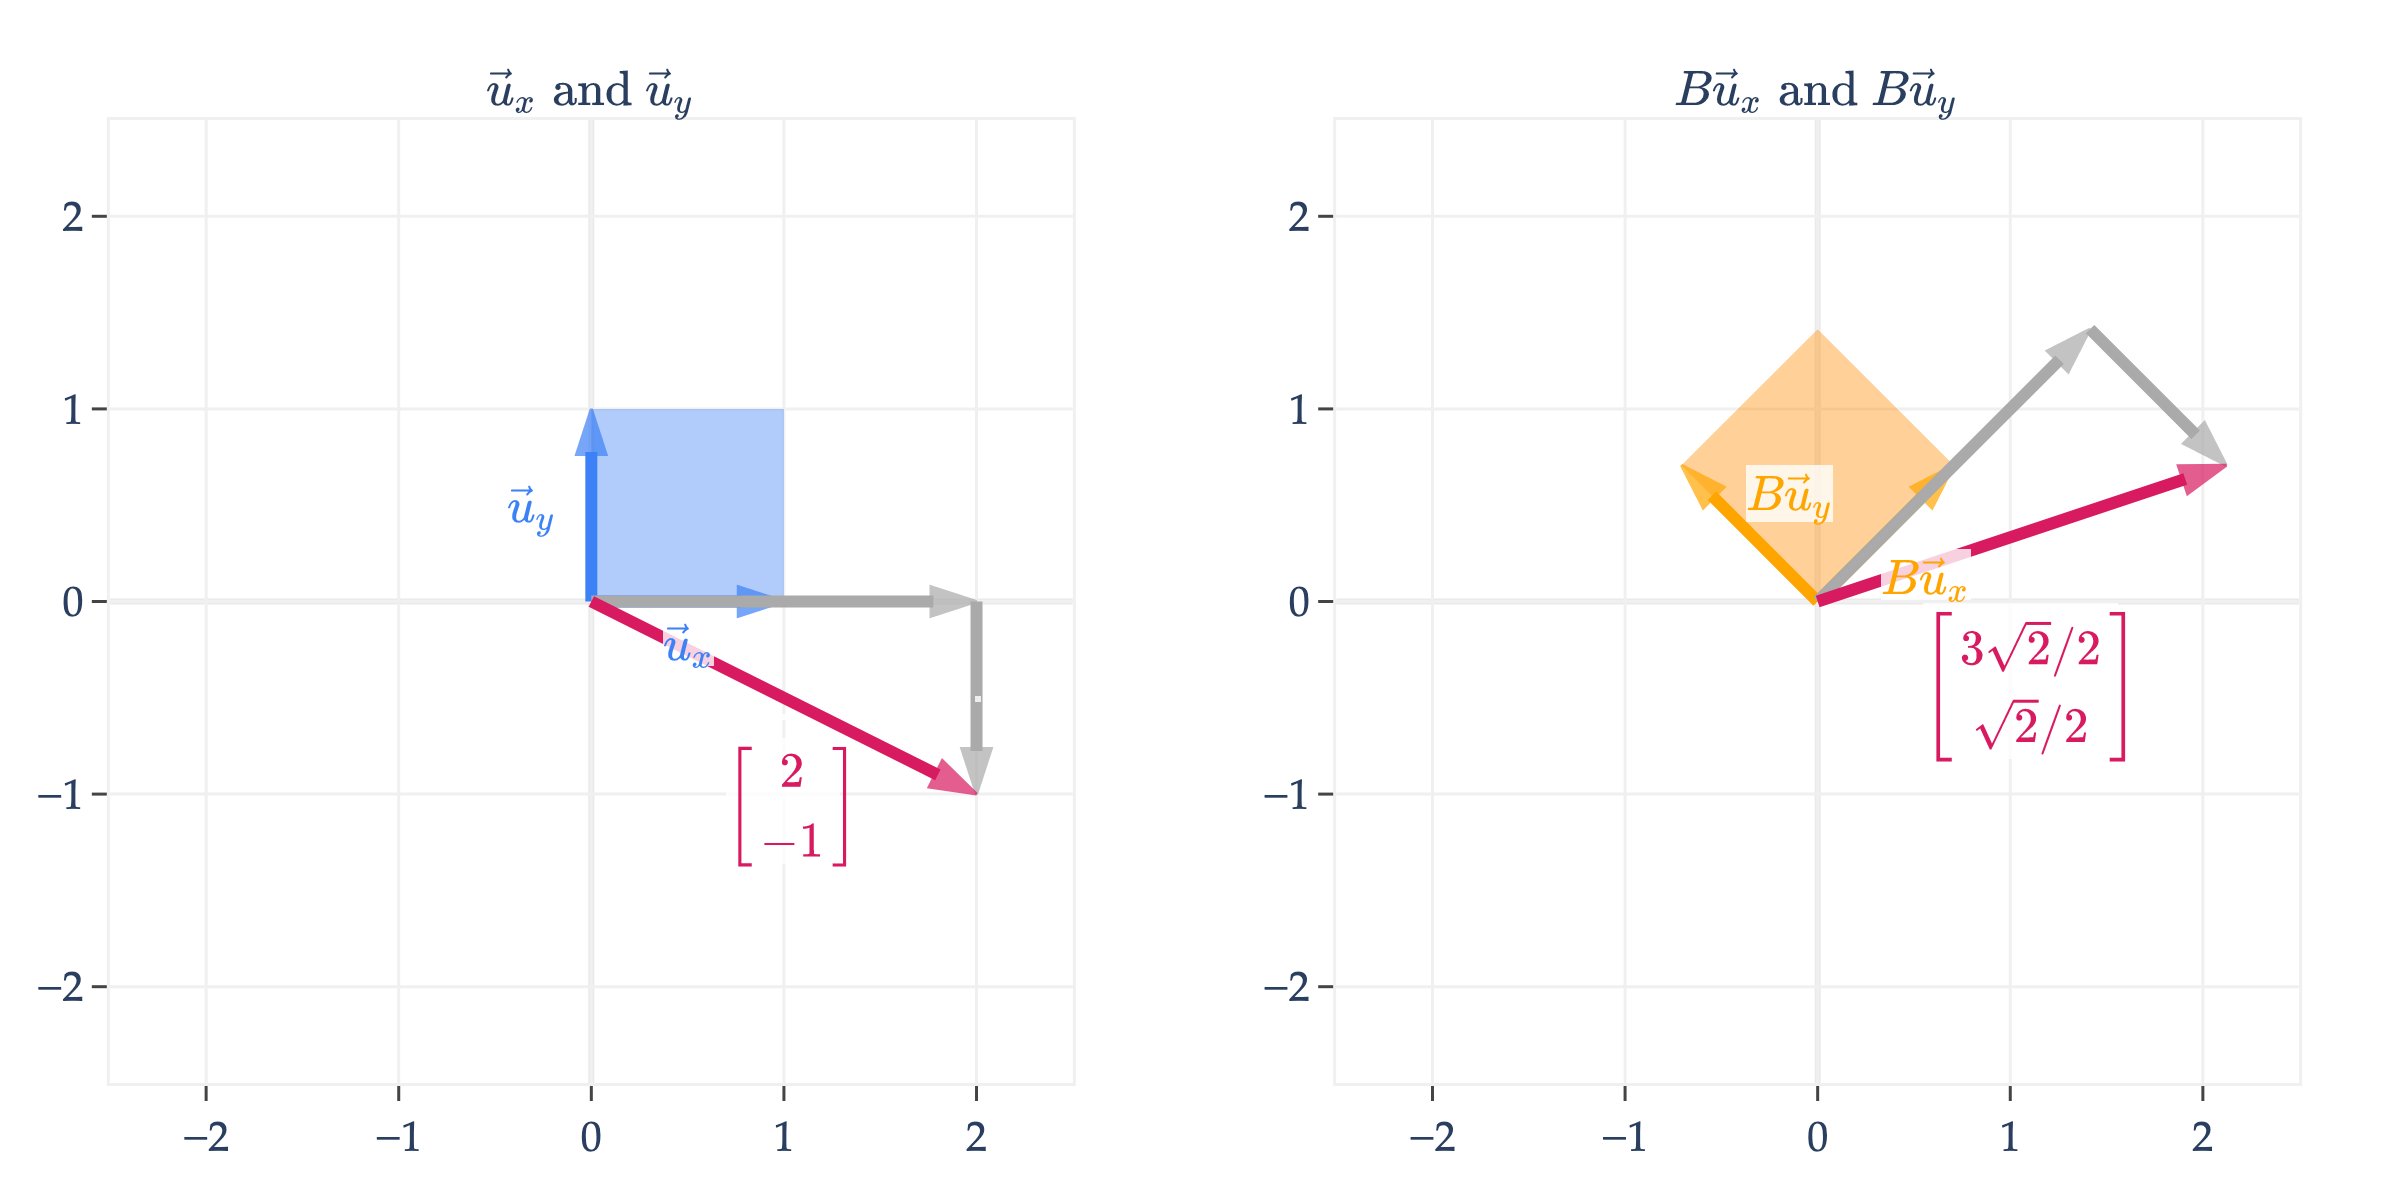

In [28]:
import numpy as np

B = np.array([[np.cos(np.pi/4), -np.sin(np.pi/4)], 
              [np.sin(np.pi/4), np.cos(np.pi/4)]])
fig = plot_unit_square_and_transform(B, name="B", vdeltay=-0.3, return_fig=True)

# Helper function to add plot_vectors traces/annotations
def add_vectors_to_subplot(fig, list_of_vecs, start_points, colors, labels, vdeltax=0, vdeltay=0, row=1, col=1):
    from utils import plot_vectors
    vec_traces = []
    # Start each vector at the specified start; plot_vectors expects (vec, color, label) triples
    triples = []
    for v, clr, lbl in zip(list_of_vecs, colors, labels):
        triples.append((tuple(v), clr, lbl))
    # plot_vectors always starts at (0,0), so to produce origins elsewhere, need to shift result traces
    base_fig = plot_vectors(triples, vdeltax=vdeltax, vdeltay=vdeltay)
    for idx, v in enumerate(list_of_vecs):
        tr = base_fig.data[idx]
        # Compute offset to move trace if needed:
        start = np.asarray(start_points[idx])
        # plot_vectors always [0, v[0]], [0, v[1]]; shift by start
        # Only shift actual vector portions, not markers etc.
        tr_shifted = tr
        # plotly.graph_objs.Scatter are immutable, so must copy with updated x/y
        tr_shifted = tr_shifted.update(
            x=(start[0] + np.array(tr.x)),
            y=(start[1] + np.array(tr.y)),
            showlegend=False  # never show legend here
        )
        fig.add_trace(tr_shifted, row=row, col=col)
        # Now also add annotation
        ann = base_fig.layout.annotations[idx]
        # The annotation has fields x/y; shift annotation location as well
        if hasattr(ann, "to_plotly_json"):
            ann_dict = ann.to_plotly_json()
        else:
            ann_dict = dict(ann)
        ann_dict = {k: v for k, v in ann_dict.items() if k not in {"xref", "yref", "axref", "ayref"}}
        # The text position should be shifted wrt origin exactly like the trace endpoint
        ann_dict["x"] = start[0] + ann_dict.get("x", 0)
        ann_dict["y"] = start[1] + ann_dict.get("y", 0)
        fig.add_annotation(**ann_dict, row=row, col=col)

# --- Data for both left/right panes ---
ux = np.array([1, 0])
uy = np.array([0, 1])
origin = np.array([0, 0])
vecs_L = [2 * ux, -uy, 2 * ux - uy]
starts_L = [origin, 2 * ux, origin]
colors_L = ["#aaa", "#aaa", "#d81a60"]  # blue, red, purple
labels_L = [r"$$", r"", fr"$\begin{{bmatrix}} 2 \\ -1 \end{{bmatrix}}$"]

Bux = B[:, 0]
Buy = B[:, 1]
vecs_R = [2 * Bux, -Buy, 2 * Bux - Buy]
starts_R = [origin, 2 * Bux, origin]
colors_R = ["#aaa", "#aaa", "#d81a60"]
labels_R = [r"", r"$$", fr"$\begin{{bmatrix}} 3\sqrt{{2}} / 2 \\ \sqrt{{2}} / 2 \end{{bmatrix}}$"]

add_vectors_to_subplot(fig, vecs_L, starts_L, colors_L, labels_L, row=1, col=1, vdeltay=-0.6)
add_vectors_to_subplot(fig, vecs_R, starts_R, colors_R, labels_R, row=1, col=2, vdeltay=-0.8)

fig.show(renderer='png', scale=3)

$B$ is an **orthogonal matrix**, which means that its columns are unit vectors and are orthogonal to one another.

$$\underbrace{B^TB = BB^T = I}_\text{condition for an orthogonal matrix}$$

Orthogonal matrices **rotate** vectors in the input space. In general, a matrix that rotates vectors by $\theta$ (radians) counterclockwise in $\mathbb{R}^2$ is given by

$$R(\theta) = \begin{bmatrix} \cos \theta & -\sin \theta \\ \sin \theta & \cos \theta \end{bmatrix}$$

$B = R(\frac{\pi}{4})$ rotates vectors by $\frac{\pi}{4}$ radians, i.e. $45^\circ$.

Rotations are more difficult to visualize in $\mathbb{R}^3$ and higher dimensions, but in Homework 5, you'll prove that orthogonal matrices preserve **norms**, i.e. if $Q$ is an $n \times n$ orthogonal matrix and $x \in \mathbb{R}^n$, then $\|Qx\| = \|x\|$. So, even though an orthogonal matrix might be doing something harder to describe in $\mathbb{R}^{15}$, we know that it isn't changing the lengths of the vectors it's multiplying.

To drive home the point I made earlier, any vector $\vec v = \begin{bmatrix} x \\ y \end{bmatrix}$, once multiplied by $B$, ends up transforming into

$$B \underbrace{\begin{bmatrix} x \\ y \end{bmatrix}}_{\vec v} = x ({\color{orange}{B \vec u_x}}) + y ({\color{orange}{B \vec u_y}})$$

### Composing Transformations

We can even apply multiple transformations one after another. This is called **composing** transformations. For instance,

$$C = \begin{bmatrix} \sqrt{2} & -\sqrt{2} \\ -\sqrt{2} / 6 & -\sqrt{2} / 6 \end{bmatrix}$$

is just $$C = AB = \underbrace{\begin{bmatrix} 2 & 0 \\ 0 & -1/3 \end{bmatrix}}_{\text{scale}} \underbrace{\begin{bmatrix} \sqrt{2}/2 & -\sqrt{2}/2 \\ \sqrt{2}/2 & \sqrt{2}/2 \end{bmatrix}}_{\text{rotate}}$$

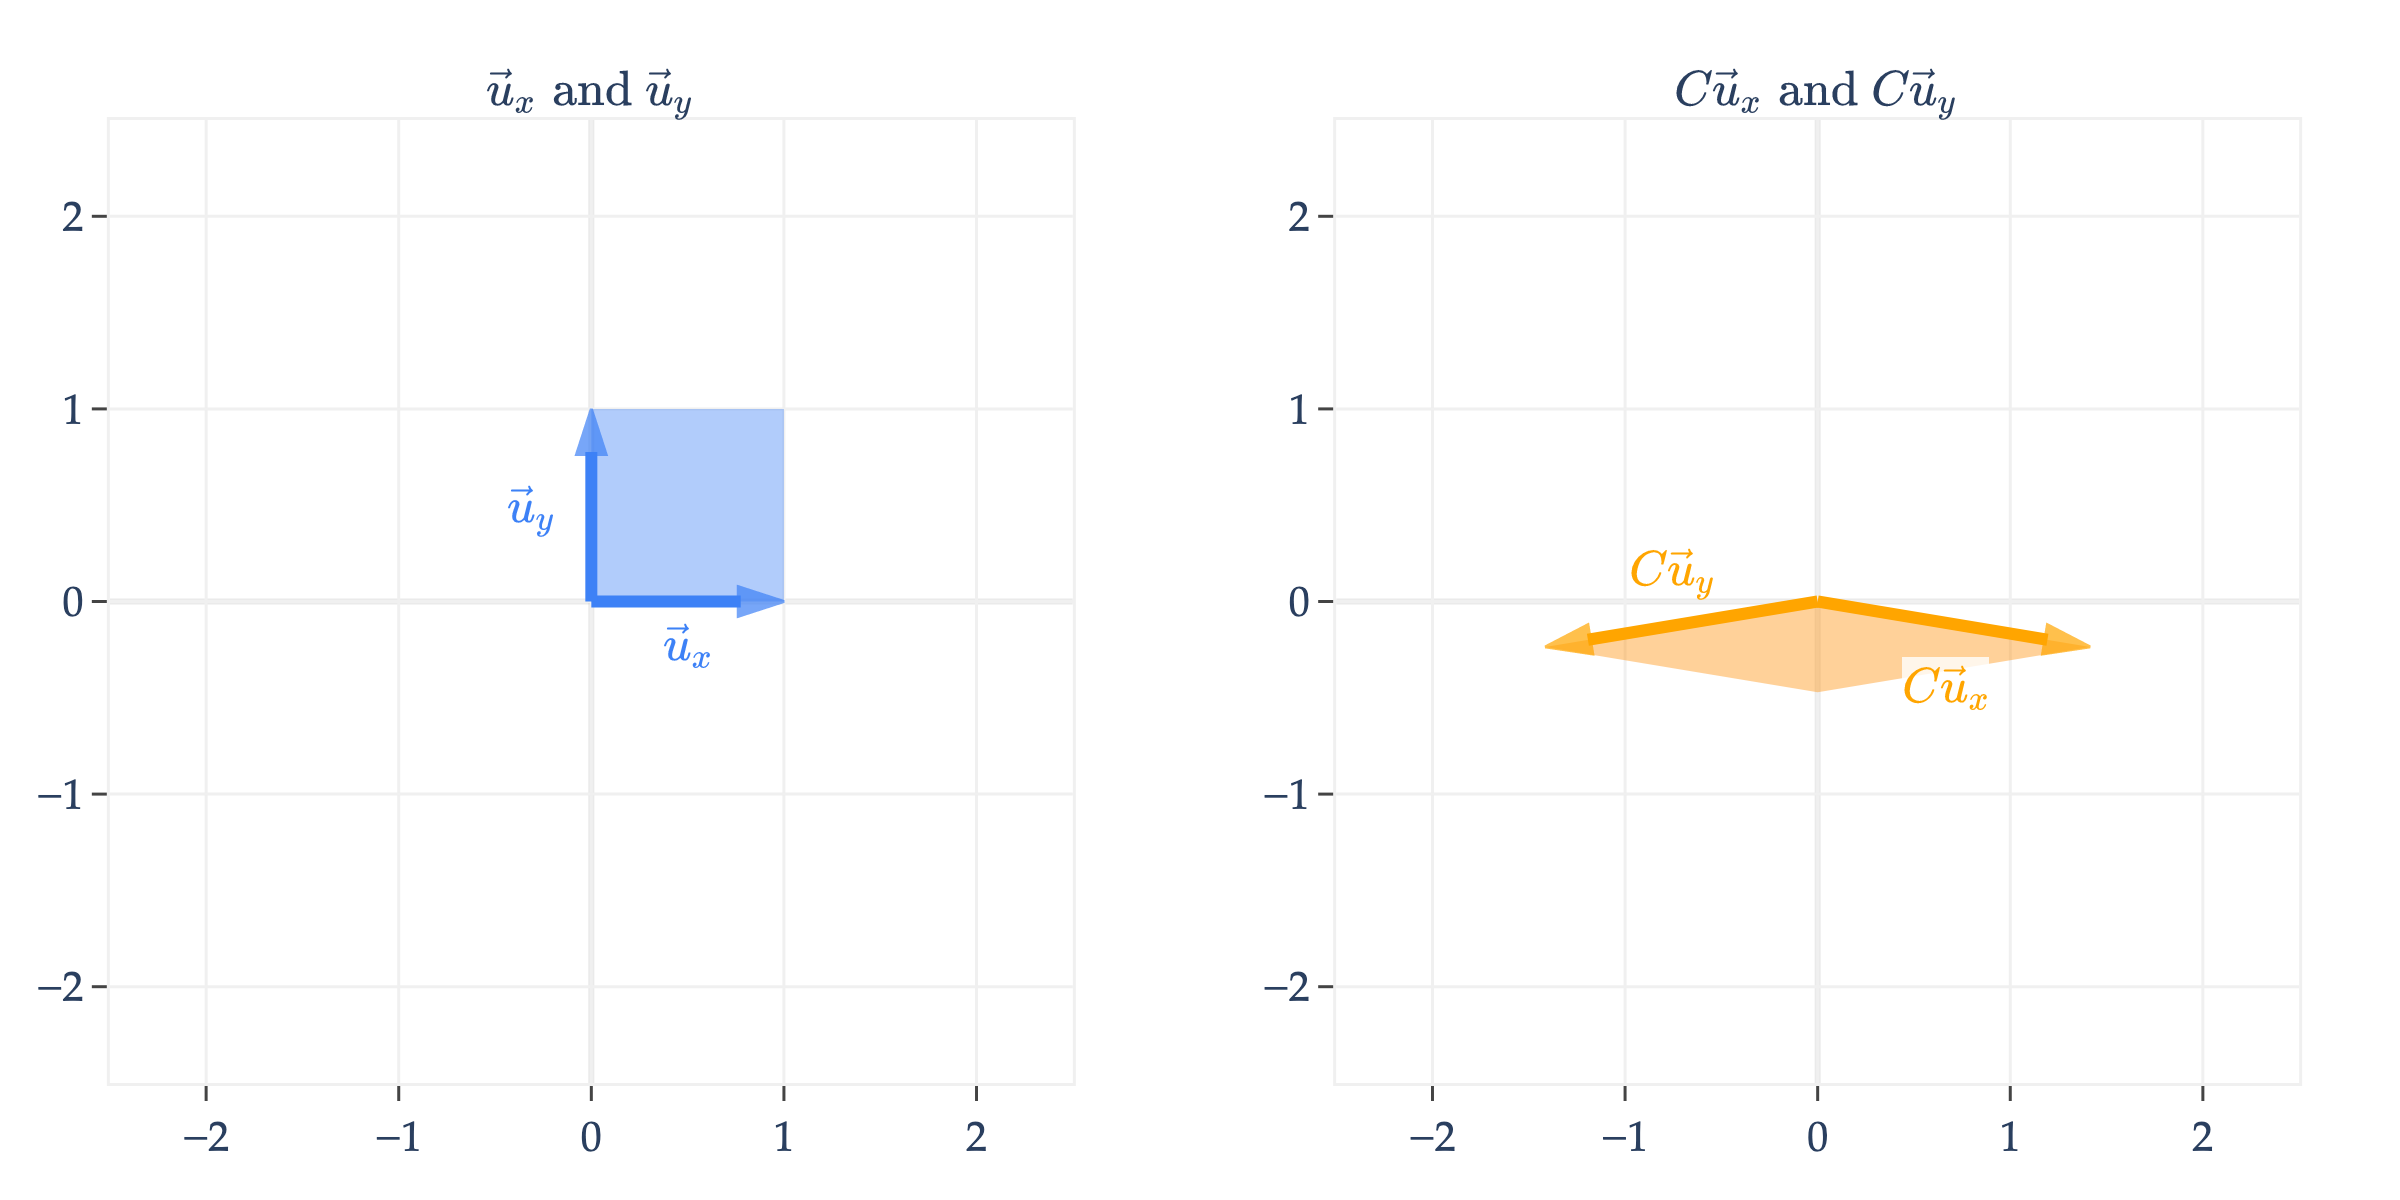

In [170]:
C = A @ B
plot_unit_square_and_transform(C, name="C", vdeltay=-0.3)

Note that $C$ rotates the input vector, **and then** scales it. Read the operations from right to left, since $C\vec x = AB \vec x = A(B \vec x)$.

$C = AB$ is different from

$$D = \begin{bmatrix} \sqrt{2} & \sqrt{2} / 6 \\ \sqrt{2} & -\sqrt{2} / 6 \end{bmatrix} = B A$$

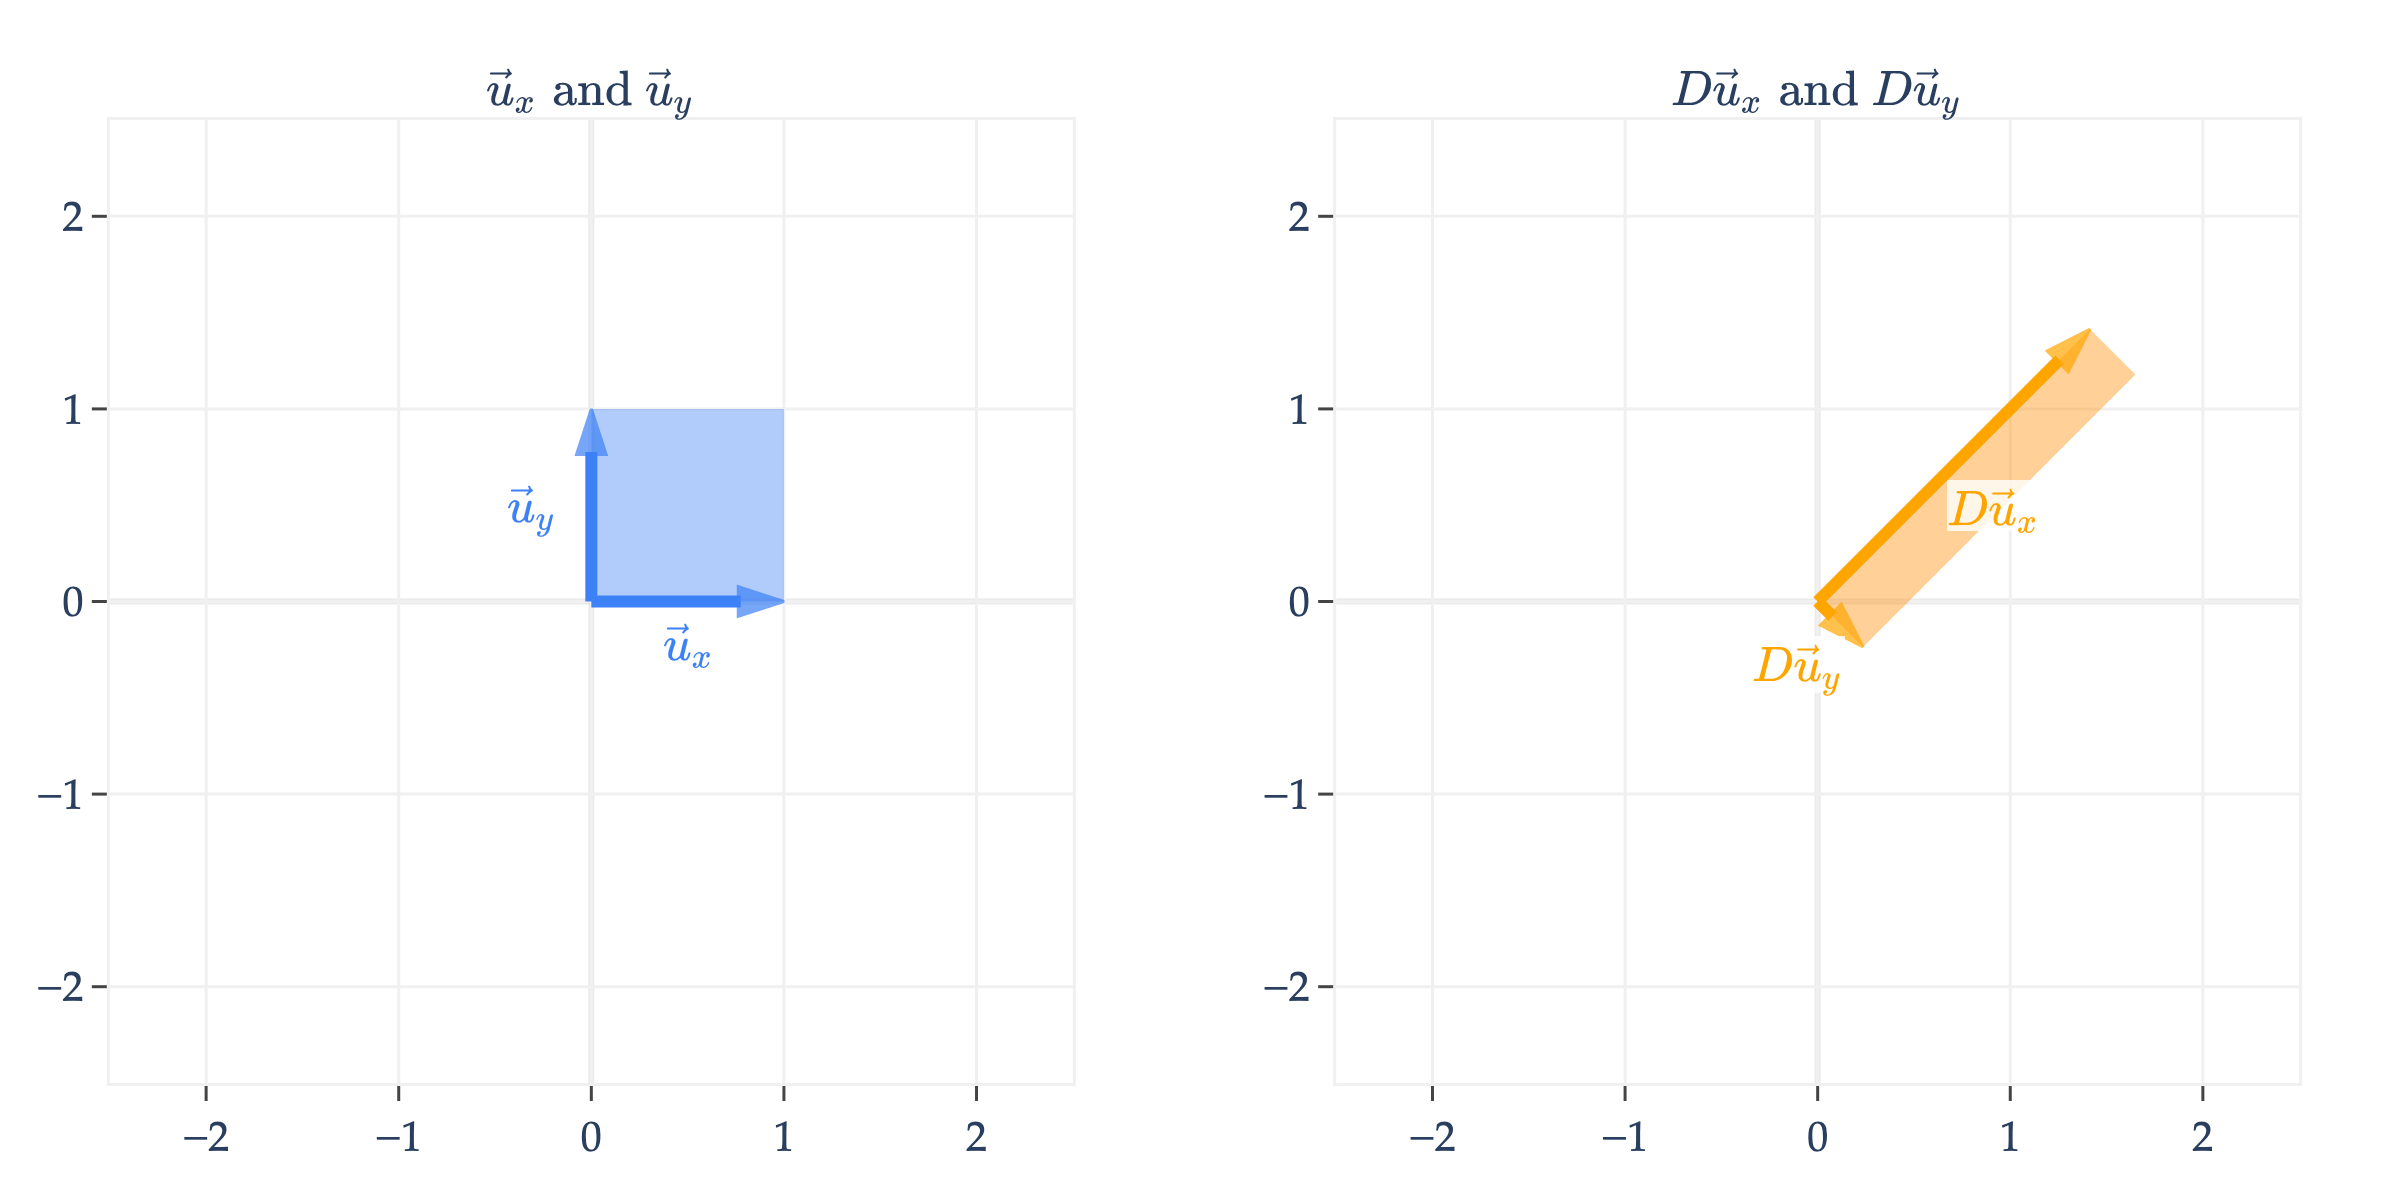

In [173]:
D = B @ A
plot_unit_square_and_transform(D, name="D", vdeltay=-0.3)

### Shears

$$E = \begin{bmatrix} 1 & -2/3 \\ 0 & 1 \end{bmatrix}$$

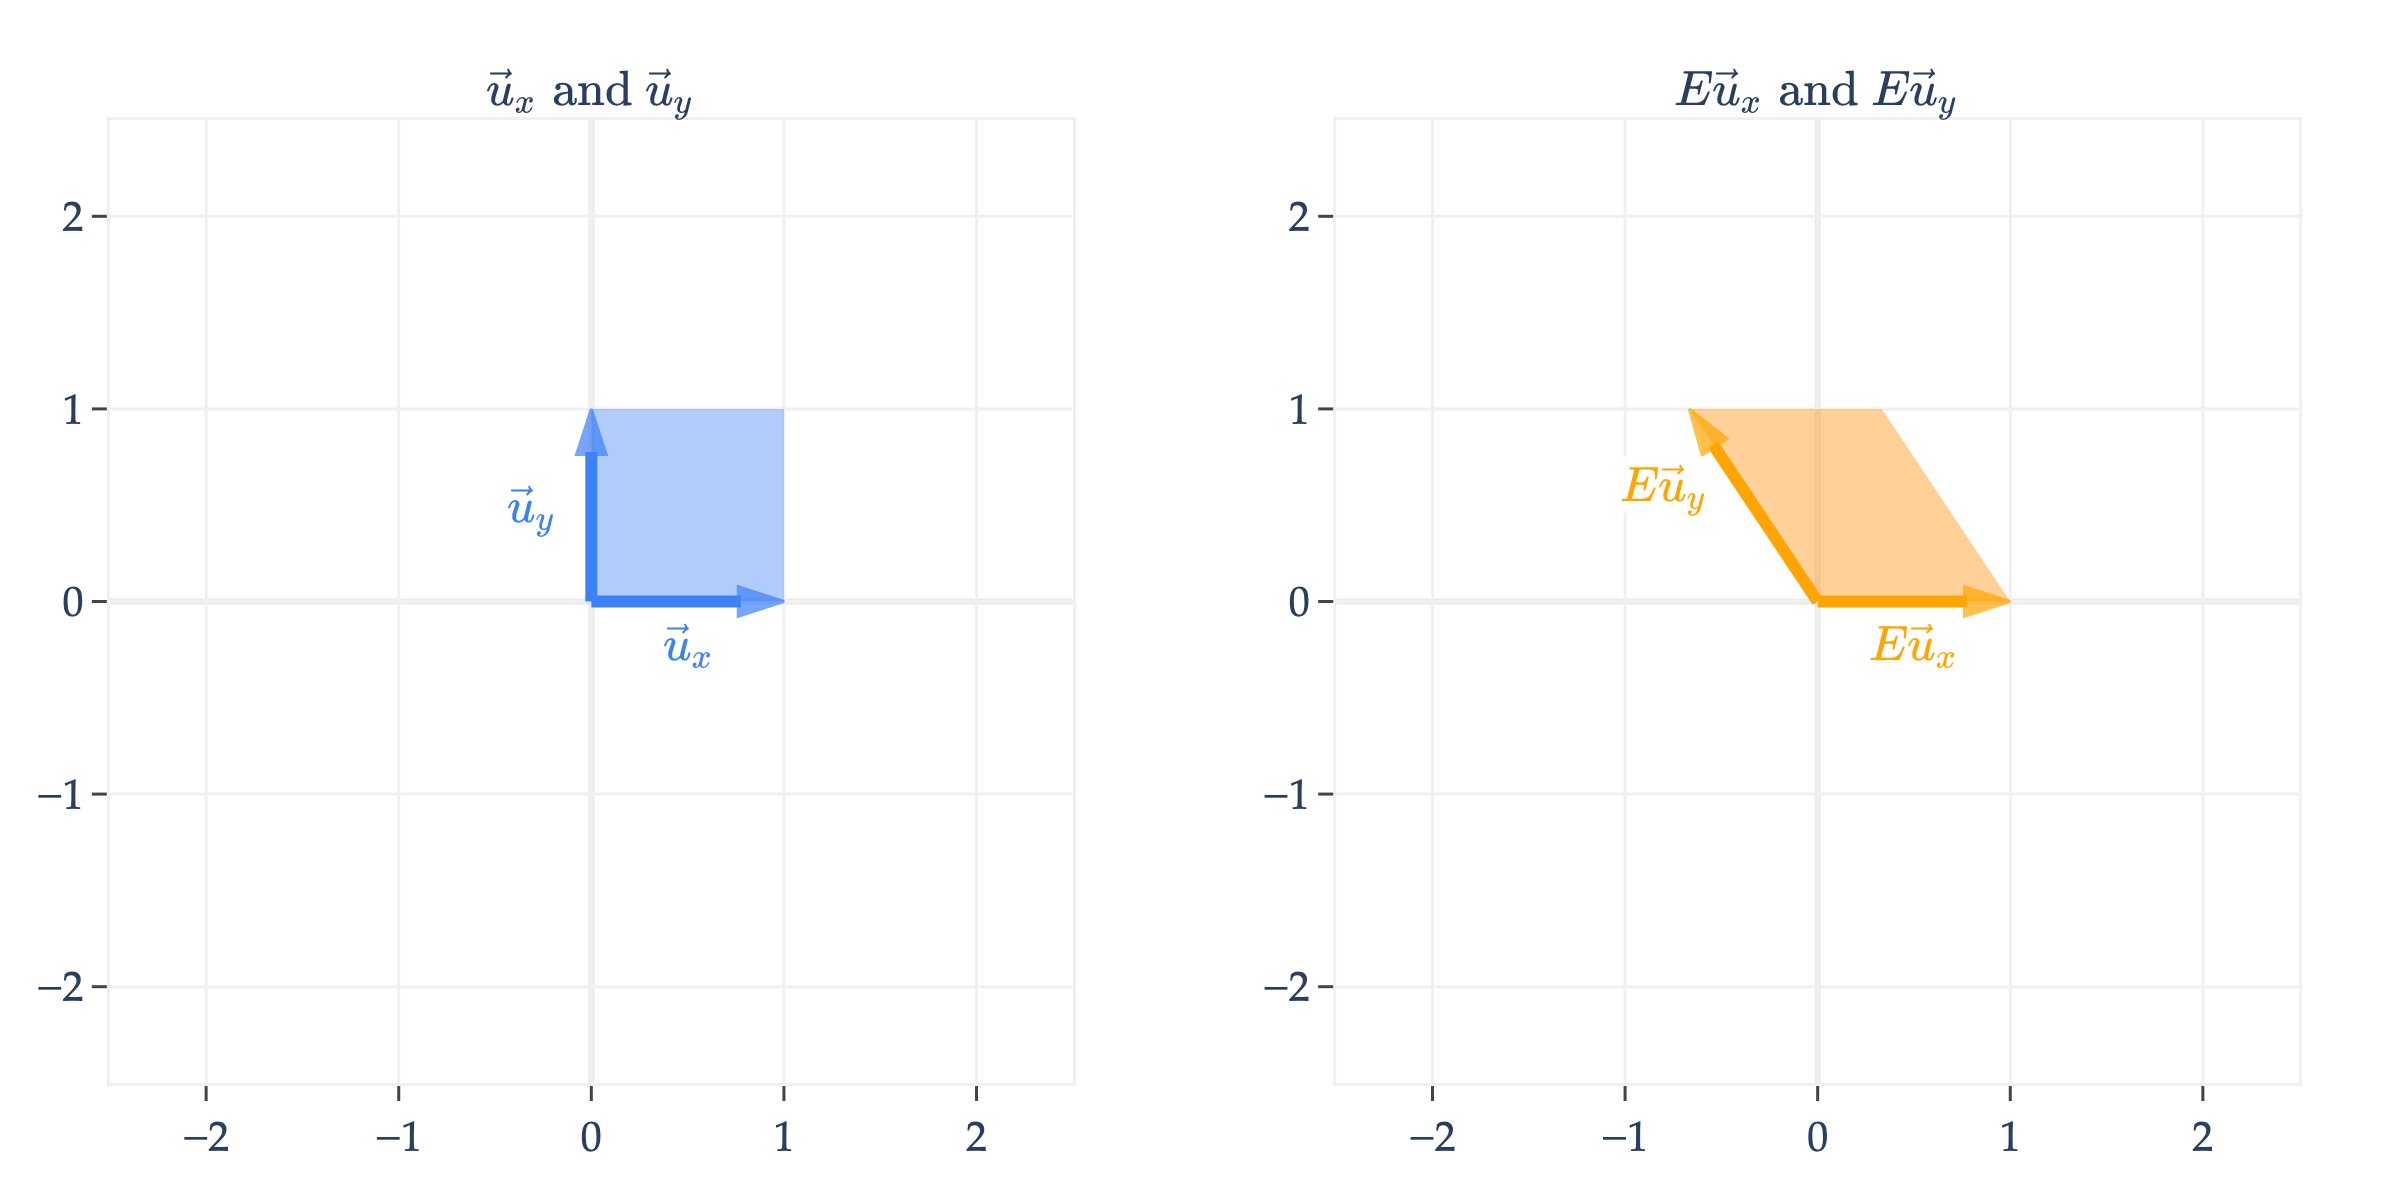

In [182]:
E = np.array([[1, -2 / 3], [0, 1]])
plot_unit_square_and_transform(E, name="E", vdeltay=-0.2, vdeltax=0.55)

$E$ is a **shear matrix**. Think of a shear as a transformation that slants the input space along one axis, while keeping the other axis fixed. What helps me interpret shears is looking at them formulaically.

$$E \begin{bmatrix} x \\ y \end{bmatrix} = \begin{bmatrix} 1 & -2/3 \\ 0 & 1 \end{bmatrix} \begin{bmatrix} x \\ y \end{bmatrix} = \begin{bmatrix} x - 2/3 y \\ y \end{bmatrix}$$

Note that the $y$-coordinate of input vectors in $\mathbb{R}^2$ remain unchanged, while the $x$-coordinate is shifted by $-\frac{2}{3}y$, which results in a slanted shape.

Similarly, $F$ is a shear matrix that keeps the $x$-coordinate fixed, but shifts the $y$-coordinate, resulting in a slanted shape that is tilted downwards.

$$F = \begin{bmatrix} 1 & 0 \\ -5/4 & 1 \end{bmatrix}$$

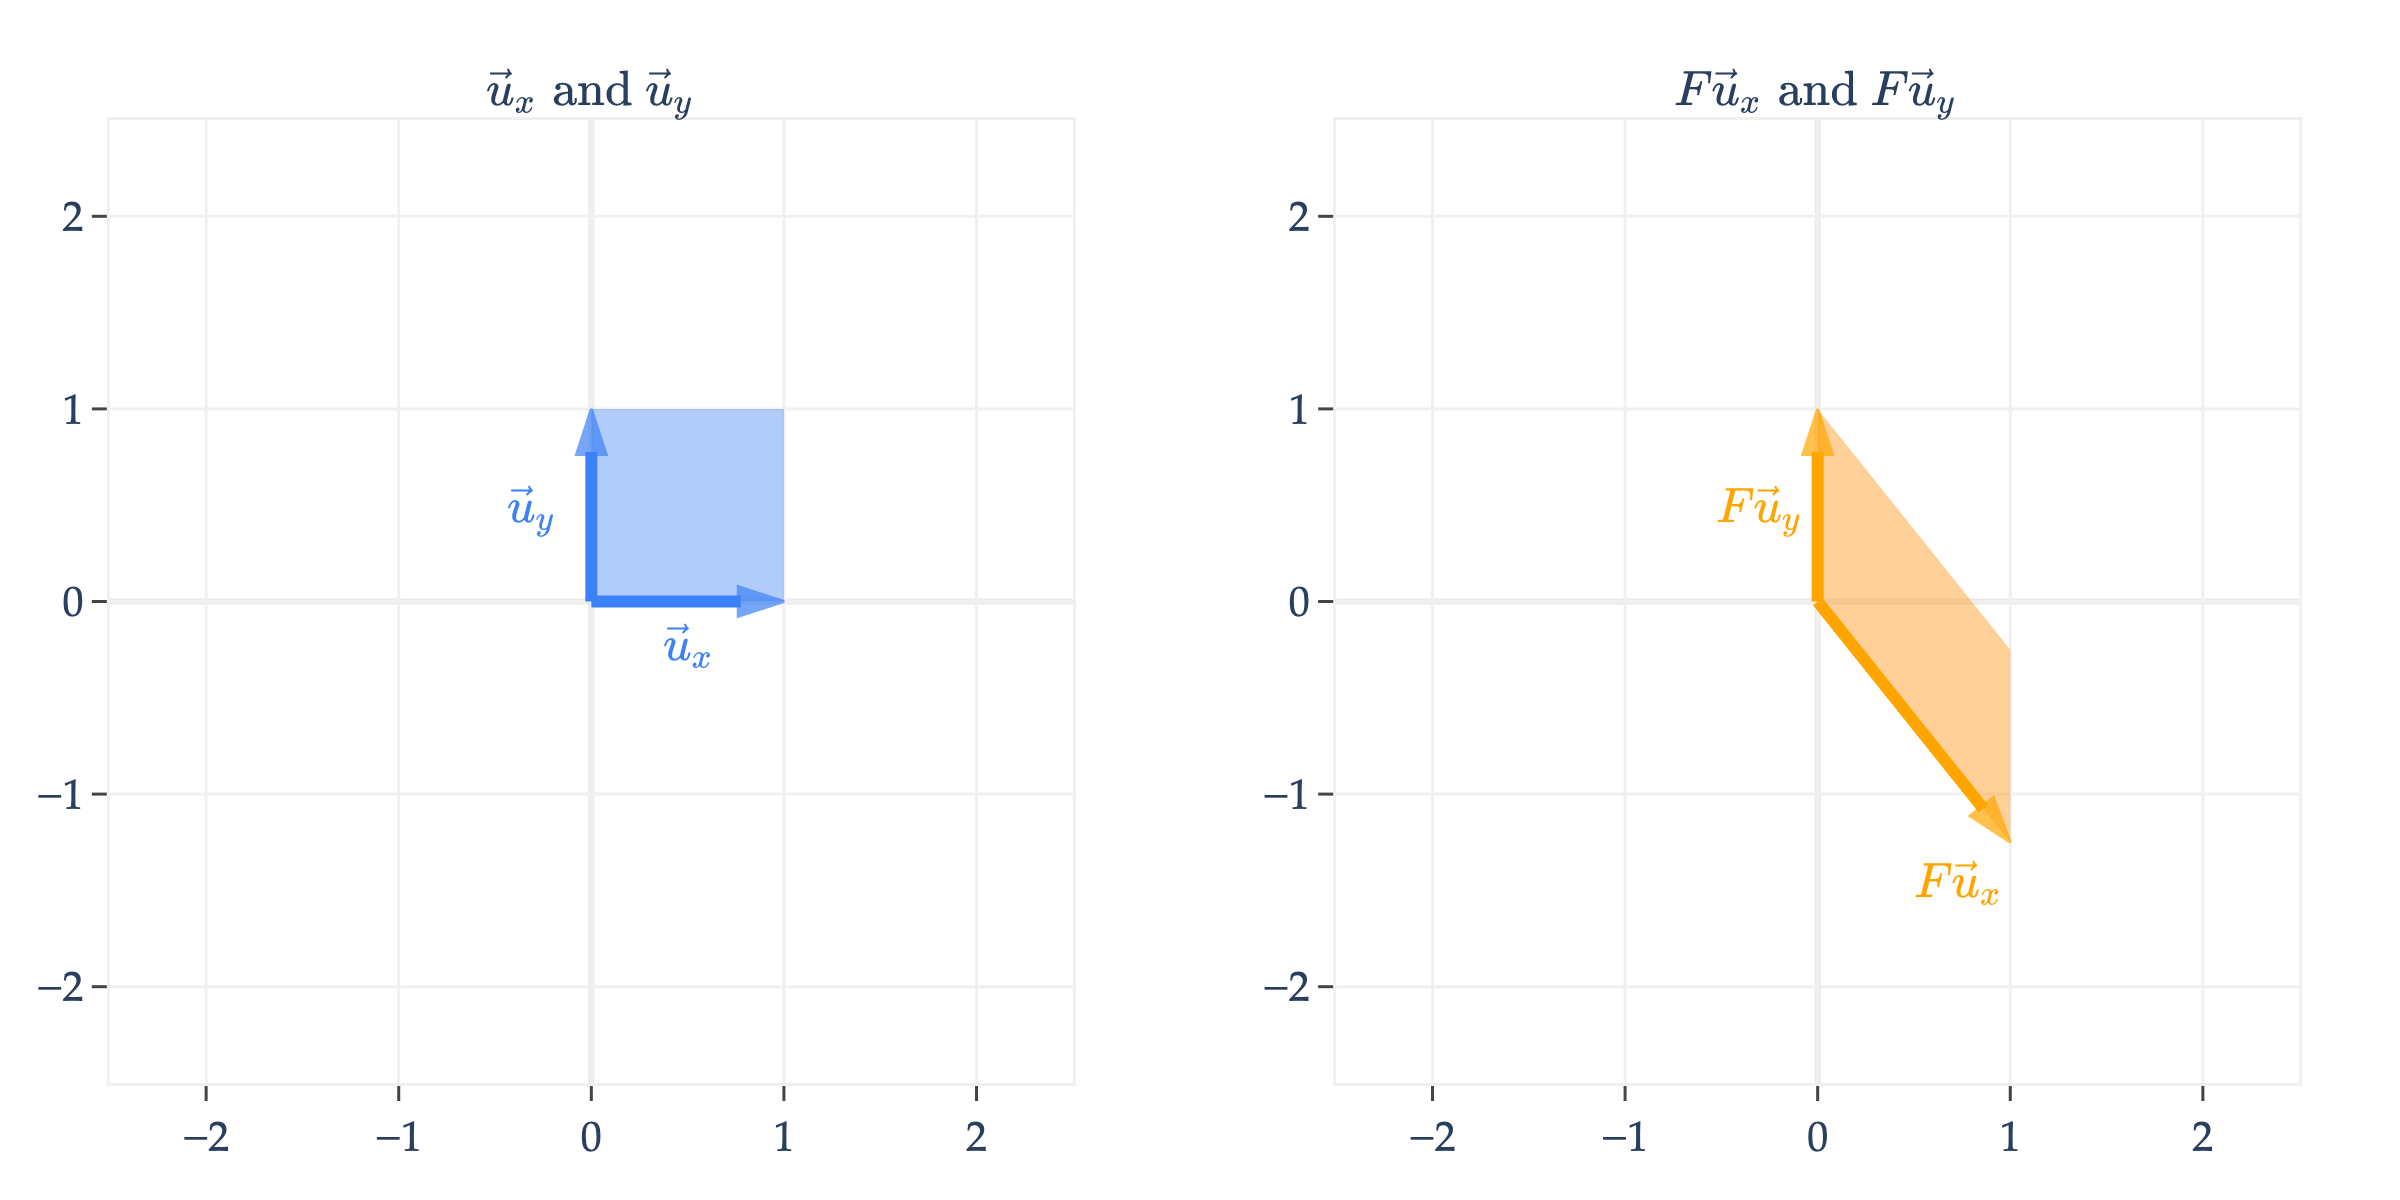

In [191]:
F = np.array([[1, 0], [-5 / 4, 1]])
plot_unit_square_and_transform(F, name="F", vdeltay=-1.3, vdeltax=0.3)

### Non-Invertible Transformations

So far we've looked at **scaling**, **rotation**, and **shear** matrices. Let's look at another type of transformation that behaves differently from what we've seen so far. Consider the matrix $G$ below.

$$G = \begin{bmatrix} 1 & 0 \\ 0 & 0 \end{bmatrix}$$

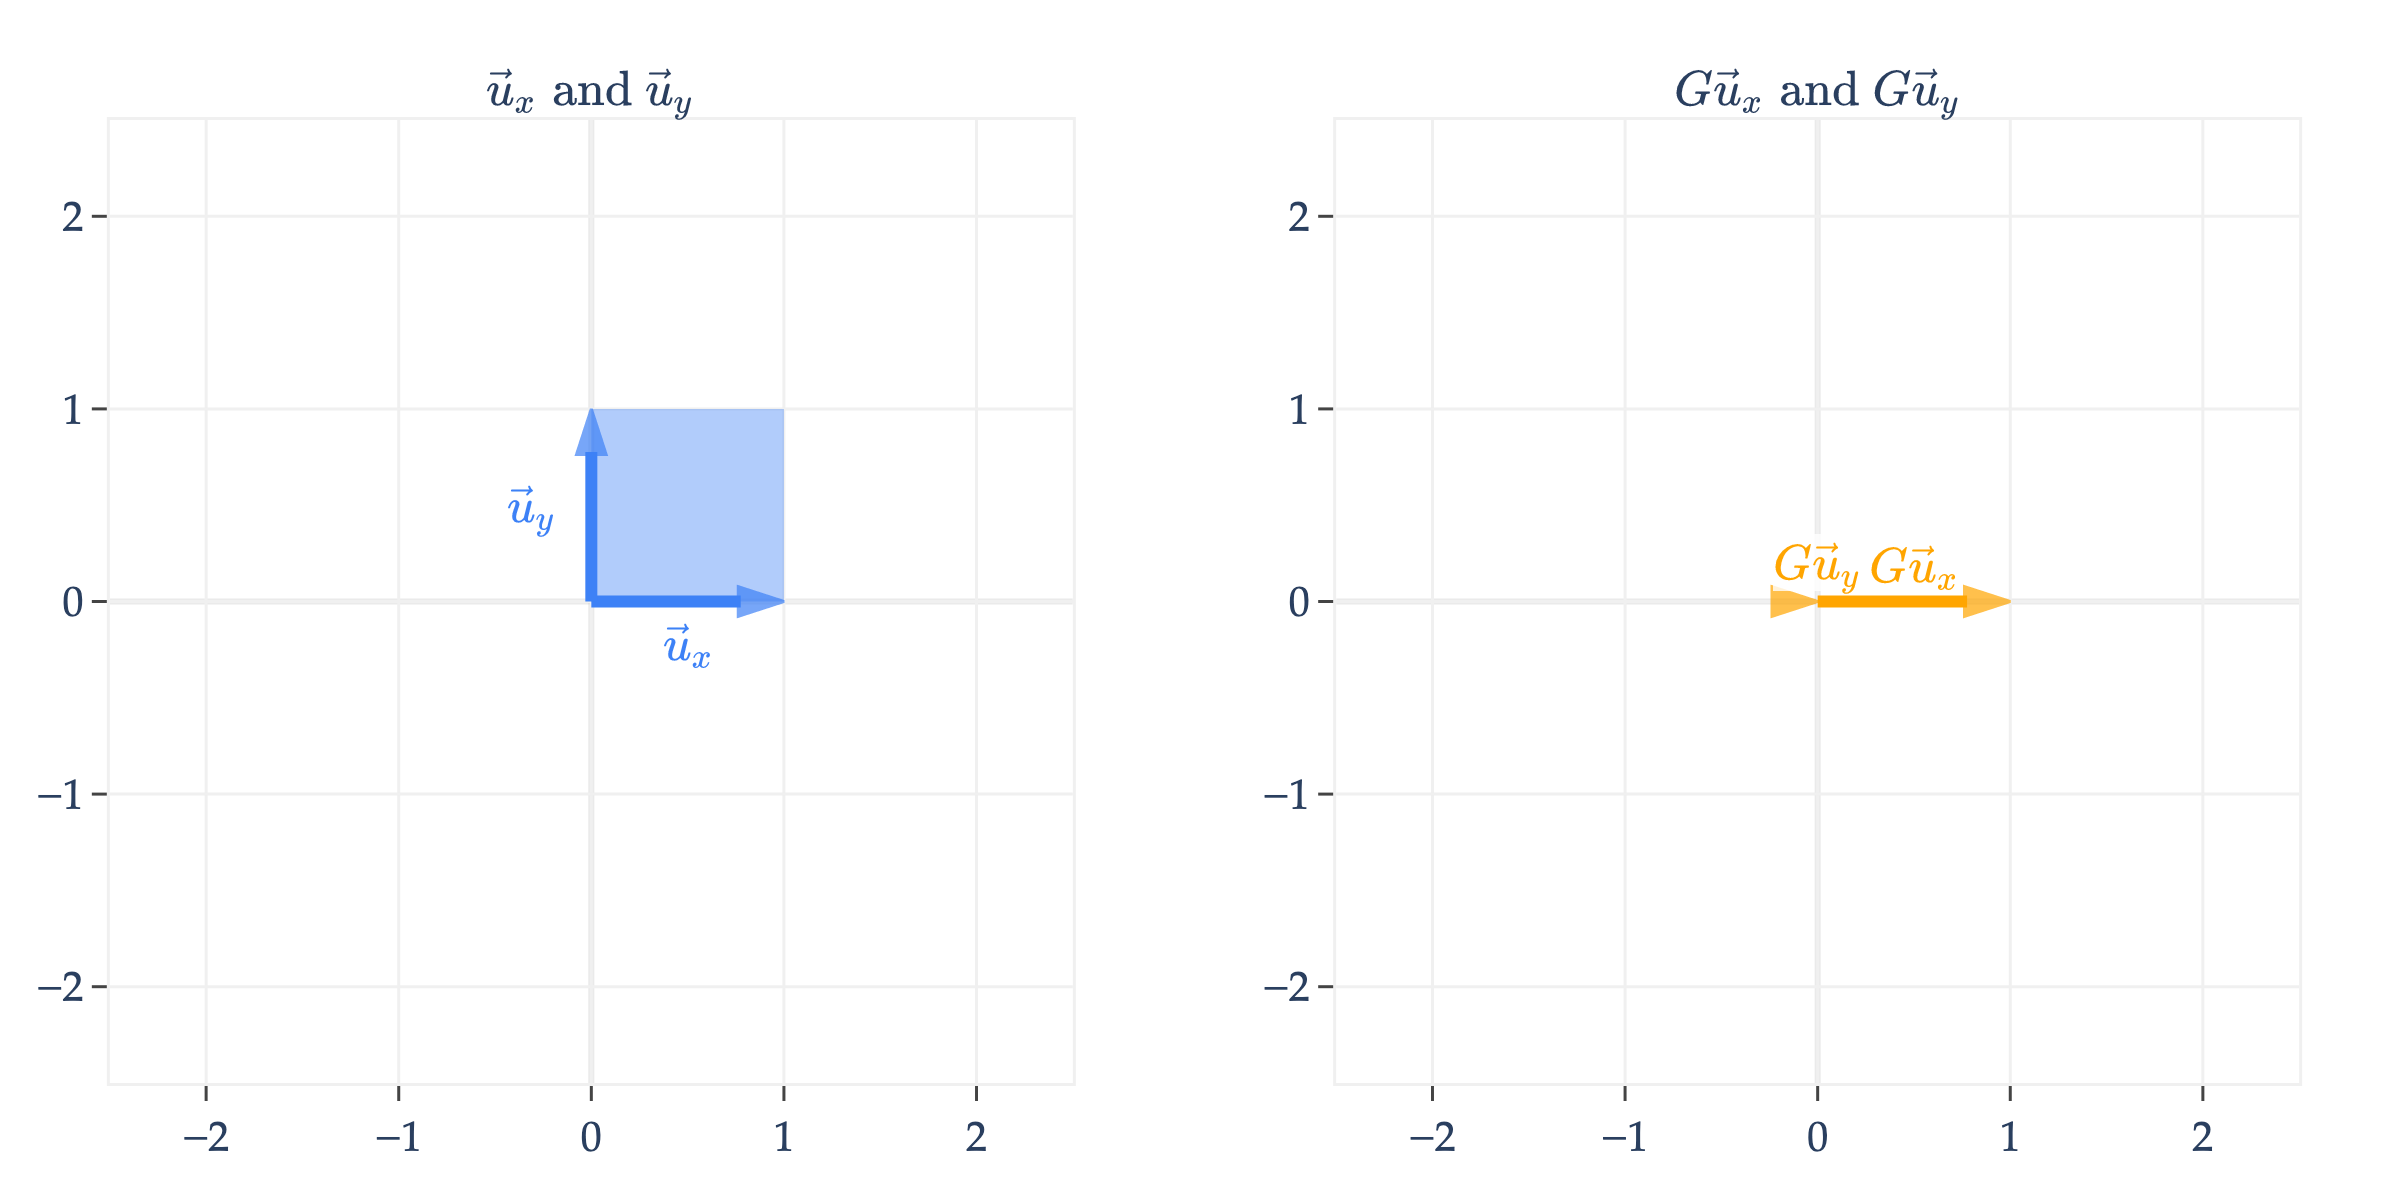

In [192]:
G = np.array([[1, 0], [0, 0]])
plot_unit_square_and_transform(G, name="G")

$G \vec x$ keeps the horizontal component of $\vec x$ and throws away the vertical component. Note that $G$ maps the unit square to a **line**, not another four-sided shape. 

Why have I called this a non-invertible transformation? This is the key idea that we're building towards: given that $G \vec x = \begin{bmatrix} 2 \\ 0 \end{bmatrix}$, **I have no way of knowing what $\vec x$ is!** It could be that $\vec x = \begin{bmatrix} 2 \\ 5 \end{bmatrix}$, or $\vec x = \begin{bmatrix} 2 \\ -1 \end{bmatrix}$, or $\vec x = \begin{bmatrix} 2 \\ 100 \end{bmatrix}$, etc. These $\vec x$'s all get mapped to the same vector, $\begin{bmatrix} 2 \\ 0 \end{bmatrix}$, by $G$. This is because, unlike the matrices we've seen so far, $\text{colsp}(G)$ is **not** all of $\mathbb{R}^2$, but rather it's just a line in $\mathbb{R}^2$, since $G$'s columns are not linearly independent.

$H$ below works similarly.

$$H = \begin{bmatrix} 1 / 2 & -1 \\ 1 & -2 \end{bmatrix}$$

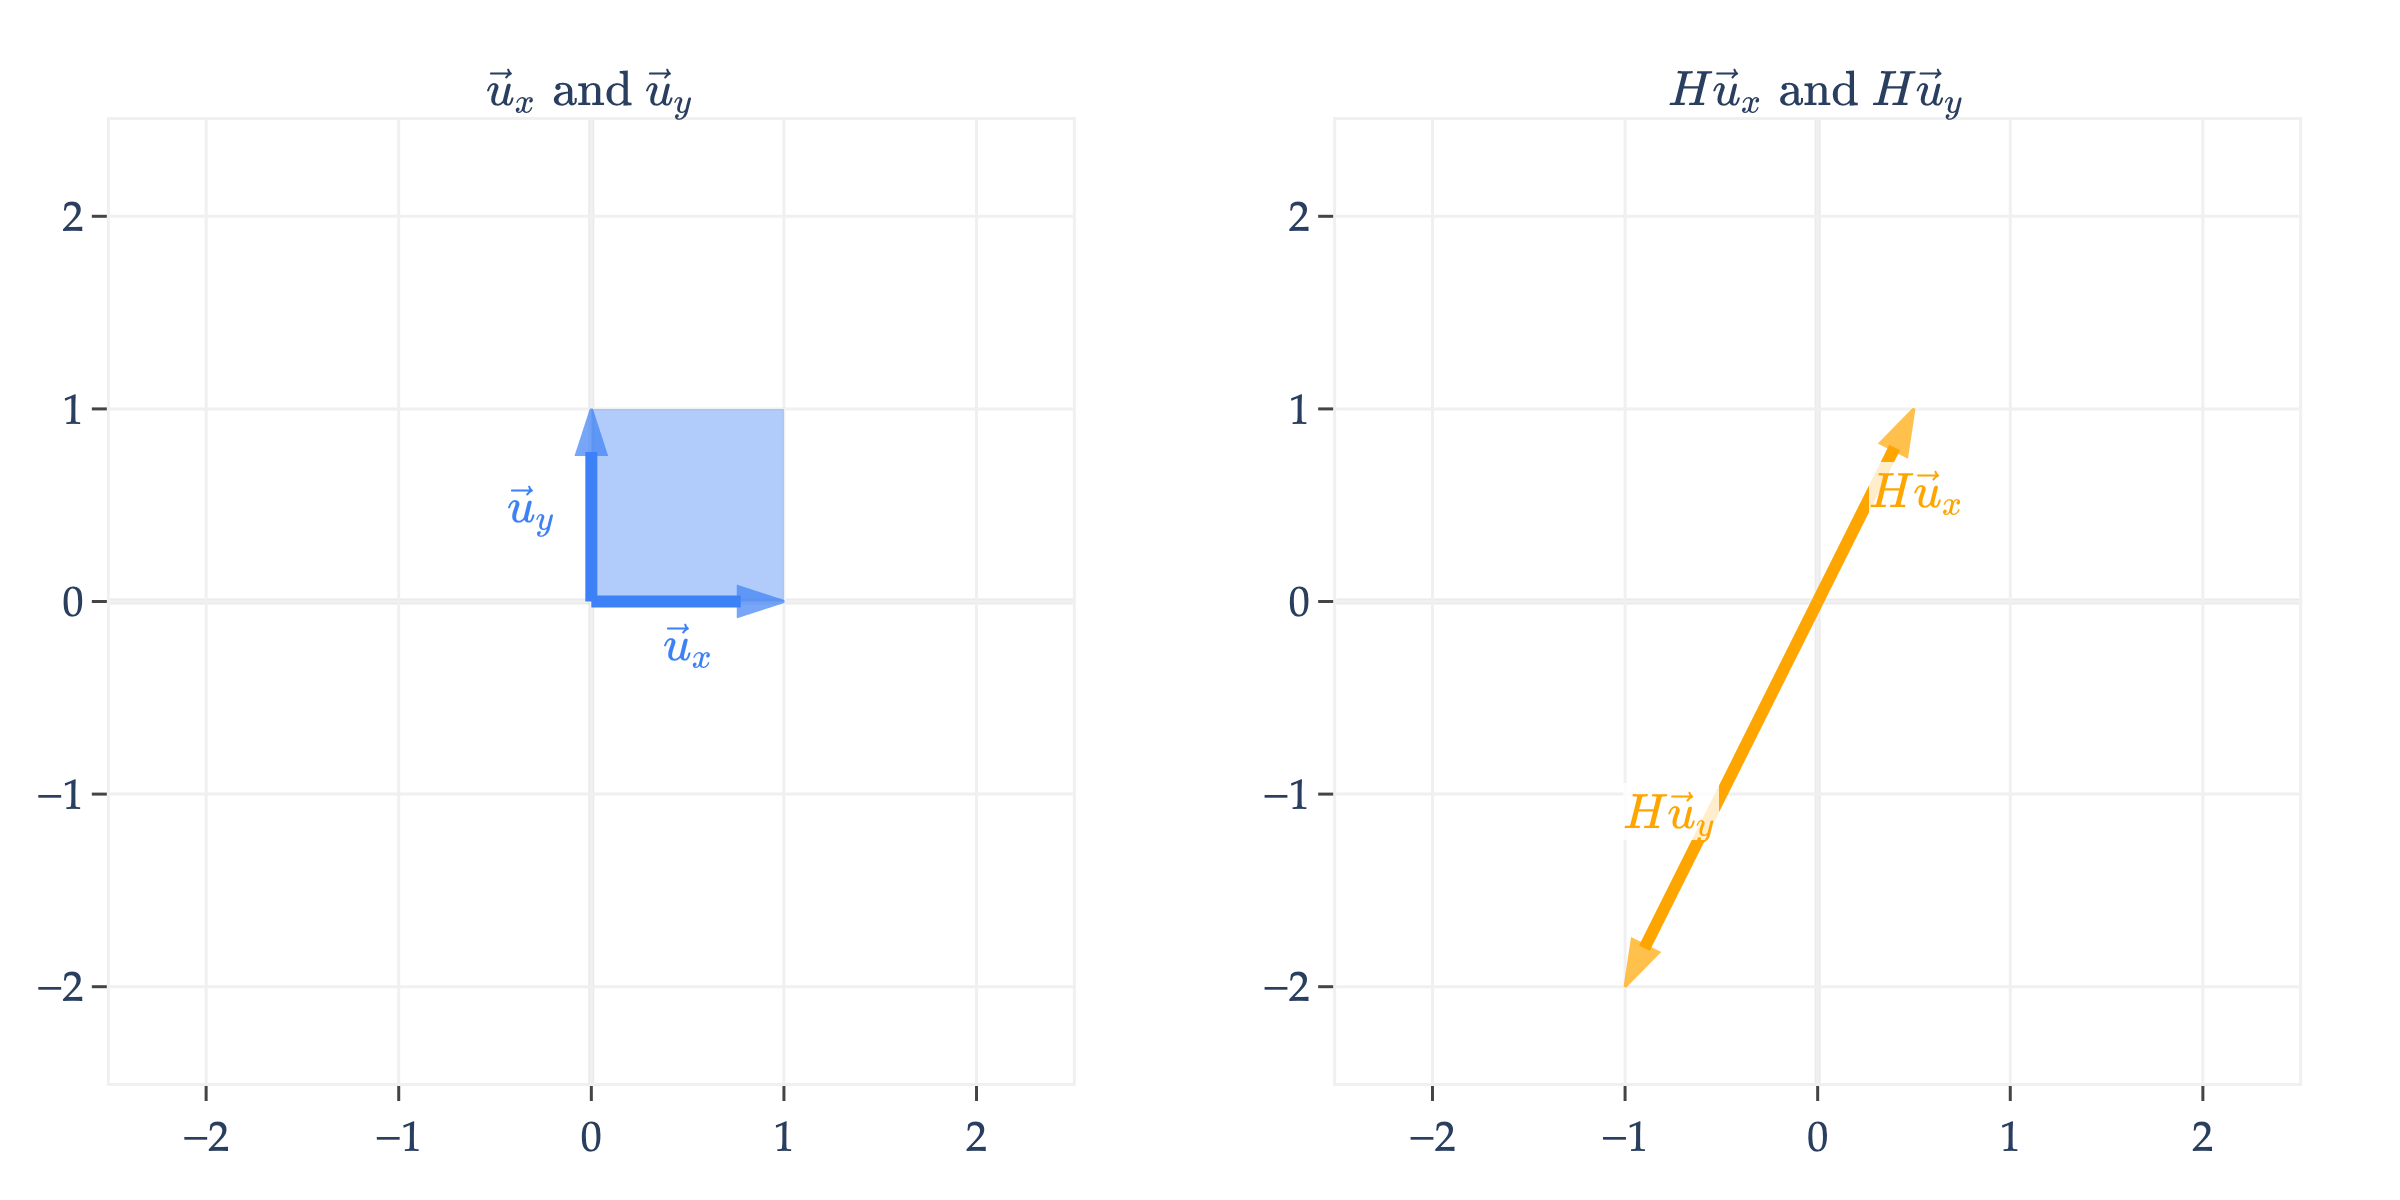

In [193]:
H = np.array([[1 / 2, -1], [1, -2]])
plot_unit_square_and_transform(H, name="H")

$\text{colsp}(H)$ is the line spanned by $\begin{bmatrix} 1 / 2 \\ 1 \end{bmatrix}$, so $H \vec x$ will always be some vector on this line. Put another way, if $\vec v = \begin{bmatrix} x \\ y \end{bmatrix}$, then $H \vec v$ is

$$H \underbrace{\begin{bmatrix} x \\ y \end{bmatrix}}_{\vec v} = x ({\color{orange}{H \vec u_x}}) + y ({\color{orange}{H \vec u_y}})$$

but since $\color{orange}{H \vec u_x}$ and $\color{orange}{H \vec u_y}$ are both on the line spanned by $\begin{bmatrix} 1 / 2 \\ 1 \end{bmatrix}$, $H \vec v$ is really just a scalar multiple of $\begin{bmatrix} 1 / 2 \\ 1 \end{bmatrix}$.

### Arbitrary Matrices

Finally, I'll comment that not all linear transformations have a nice, intuitive interpretation. For instance, consider

$$J = \begin{bmatrix} 1 / 3 & -1 \\ 1 & -1 / 2 \end{bmatrix}$$

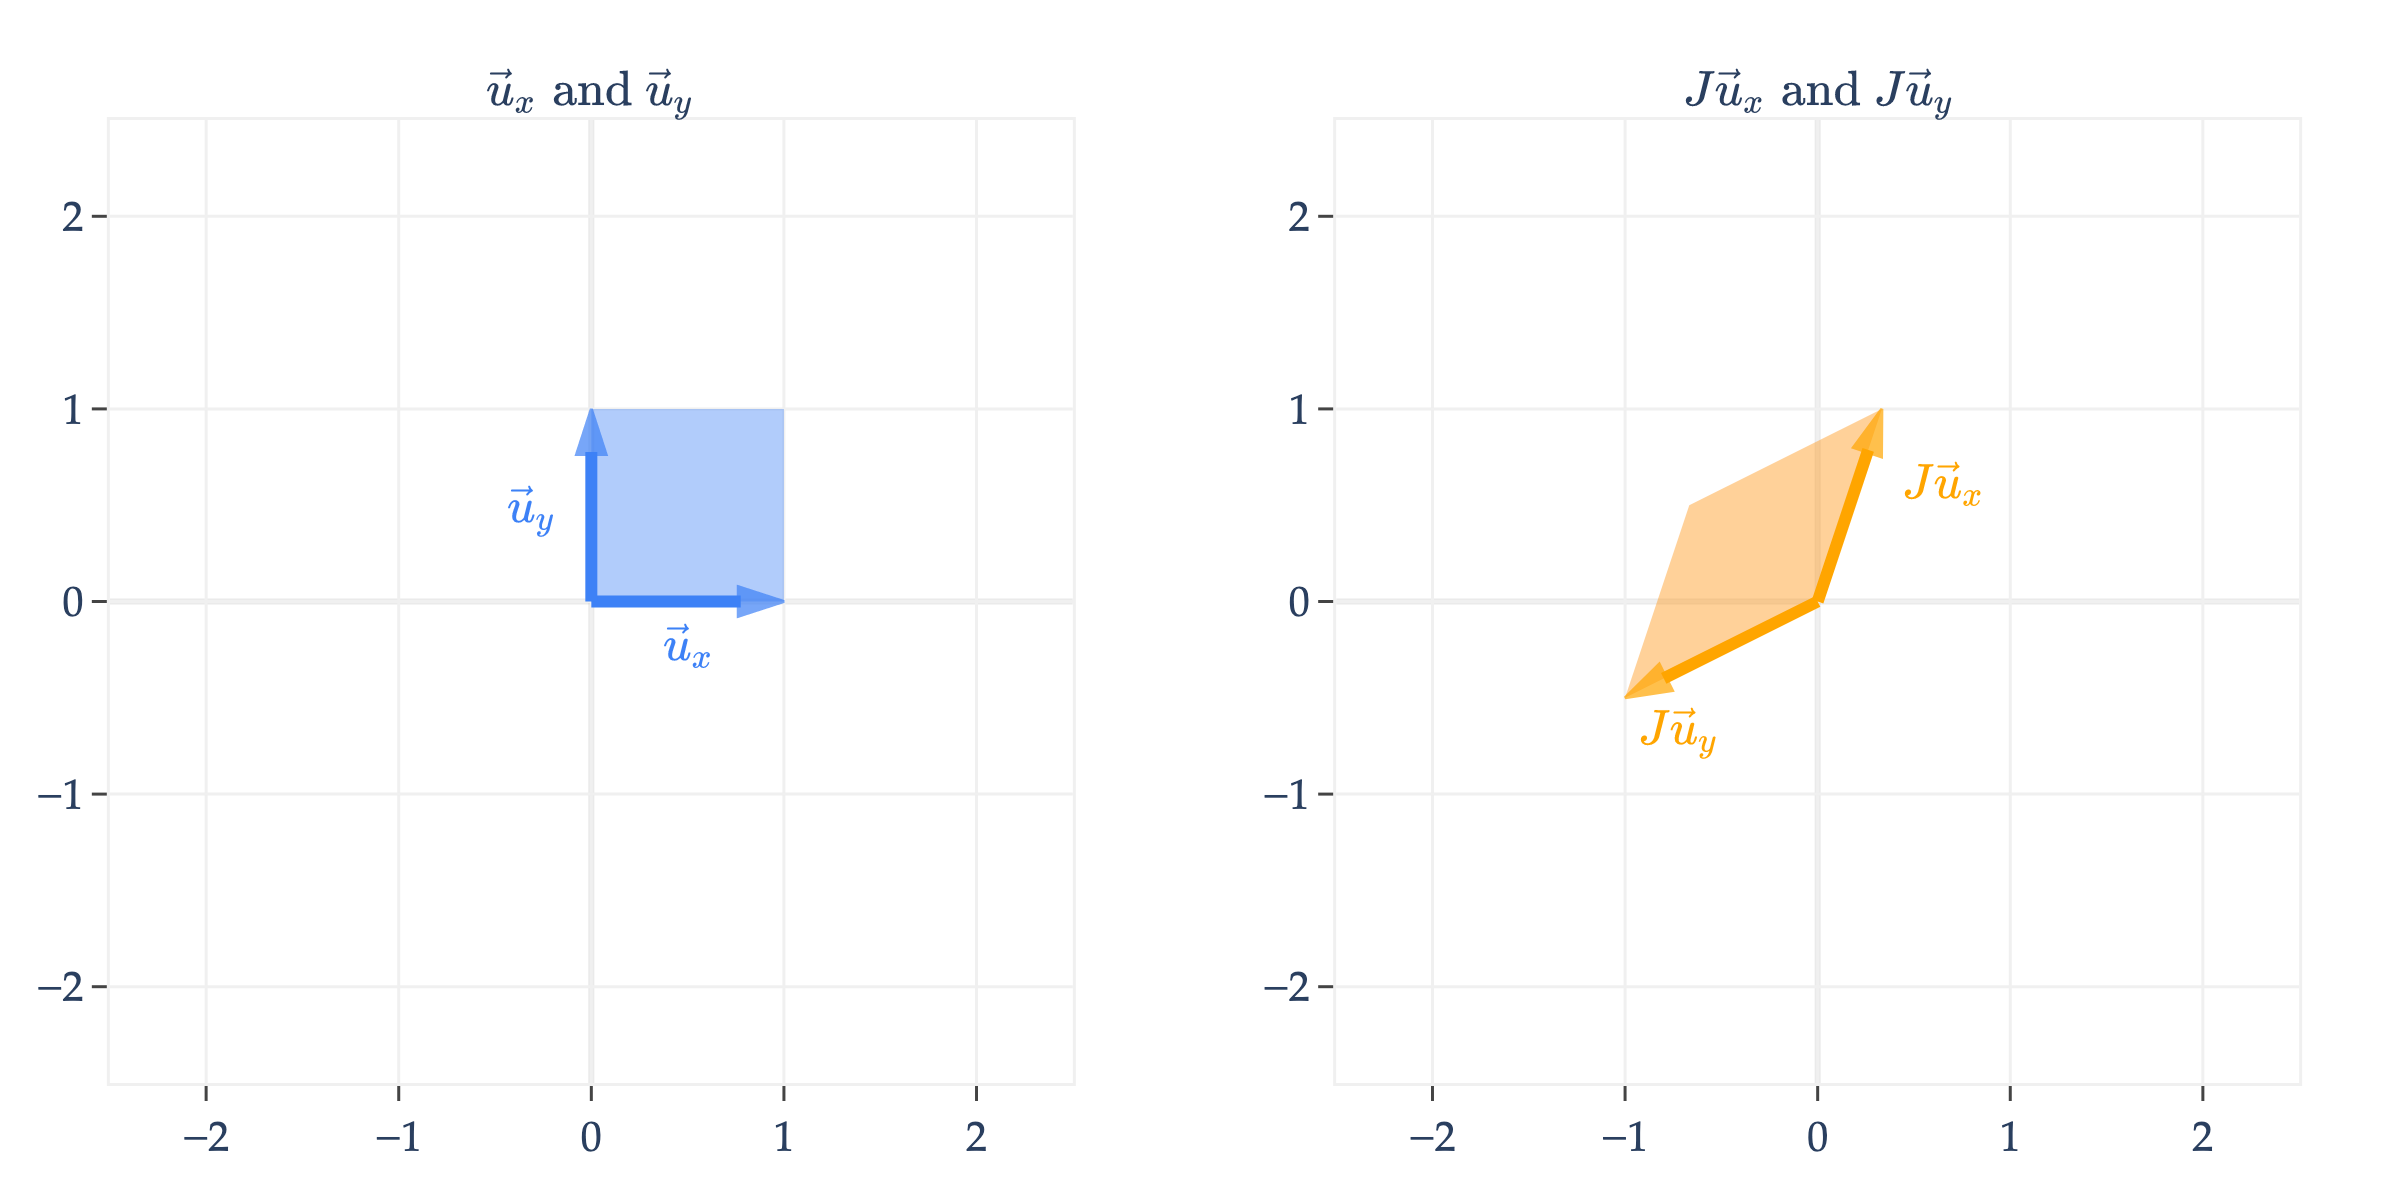

In [205]:
J = np.array([[1 / 3, -1], [1, -1 / 2]])
plot_unit_square_and_transform(J, name="J", vdeltay=0.45, vdeltax=-0.5)

$J$ turns the unit square into a **parallelogram**. In fact, so did $A$, $B$, $C$, $D$, $E$, and $F$; all of these transformations map the unit square to a parallelogram, with some additional properties (e.g. $A$'s parallelogram was a rectangle, $B$'s had equal sides, etc.).

There's no need to memorize the names of these transformations – after all, they only apply in $\mathbb{R}^2$ and perhaps $\mathbb{R}^3$ where we can visualize.

Speaking of $\mathbb{R}^3$, an arbitrary $3 \times 3$ matrix can be thought of as a transformation that maps the unit cube to a parallelepiped (the generalization of a parallelogram to three dimensions).

$$K = \begin{bmatrix} 1 & 0 & 0 \\ 0 & 2 & 1/2 \\ 0 & -1 & 1 / 2 \end{bmatrix}$$

In [233]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from utils import plot_vectors

def plot_unit_cube_and_transform(S, name="Matrix", vdeltax=-0.3, vdeltay=0.2, vdeltaz=0.2):
    """
    Visualize the action of a 2x2 or 3x3 matrix S on the unit square/cube and basis vectors.
    For 2D, shows the unit square and its image; for 3D, shows the unit cube and its image.
    """
    S = np.asarray(S)
    dim = S.shape[0]
    assert S.shape[0] == S.shape[1], "Matrix must be square"
    assert dim in (2, 3), "Only 2D or 3D matrices supported"

    if dim == 2:
        # Vertices of the unit square (closed)
        square = np.array([
            [0, 0],  # A
            [1, 0],  # B
            [1, 1],  # C
            [0, 1],  # D
        ])
        square_closed = np.vstack([square, square[0]])  # for plotting outline if needed
        square_trans = (S @ square.T).T
        square_trans_closed = np.vstack([square_trans, square_trans[0]])

        fig = make_subplots(
            rows=1, cols=2,
            horizontal_spacing=0.08,
            subplot_titles=("Original Unit Square", f"Transformed by {name}")
        )

        axis_style = dict(
            showgrid=True,
            gridcolor="#eeeeee",
            zeroline=False,
            showline=True,
            linecolor="#eeeeee",
            mirror=True,
            ticks="",  # turn off axis ticks
            showticklabels=False,  # turn off axis tick labels
            tickfont=dict(family="Palatino, serif", size=14),
        )

        for i in [1, 2]:
            fig.update_xaxes(
                range=[-2.5, 2.5],
                constrain="domain",
                dtick=1,
                **axis_style,
                row=1, col=i
            )
            fig.update_yaxes(
                range=[-2.5, 2.5],
                scaleanchor=f"x{i}",
                dtick=1,
                **axis_style,
                row=1, col=i
            )

        # Draw gridlines at x=0 and y=0 in #ccc
        for i in [1, 2]:
            fig.add_shape(
                type="line",
                x0=-2.5, x1=2.5, y0=0, y1=0,
                line=dict(color="#cccccc", width=2, dash="solid"),
                row=1, col=i,
                layer="below"
            )
            fig.add_shape(
                type="line",
                x0=0, x1=0, y0=-2.5, y1=2.5,
                line=dict(color="#cccccc", width=2, dash="solid"),
                row=1, col=i,
                layer="below"
            )

        # Plot original unit square (shaded, no boundary)
        fig.add_trace(
            go.Scatter(
                x=square_closed[:,0], y=square_closed[:,1],
                fill="toself",
                fillcolor="rgba(61,129,246,0.25)",
                line=dict(color="rgba(0,0,0,0)", width=0),
                name="Unit Square",
                showlegend=False
            ),
            row=1, col=1
        )
        # Plot transformed square (shaded, no boundary)
        fig.add_trace(
            go.Scatter(
                x=square_trans_closed[:,0], y=square_trans_closed[:,1],
                fill="toself",
                fillcolor="rgba(255,140,0,0.25)",
                line=dict(color="rgba(0,0,0,0)", width=0),
                name="Transformed Square",
                showlegend=False
            ),
            row=1, col=2
        )

        # --- Draw vectors using plot_vectors ---
        u_x = np.array([1, 0])
        u_y = np.array([0, 1])
        Su_x = S @ u_x
        Su_y = S @ u_y

        # Only draw the border for the basis vectors
        left_vecs = [
            (tuple(u_x), '#3d81f6', None),
            (tuple(u_y), '#3d81f6', None)
        ]
        left_fig = plot_vectors(left_vecs, vdeltay=-0.2)
        left_fig.update_layout(
            plot_bgcolor="white",
            paper_bgcolor="white",
            xaxis=dict(visible=False),
            yaxis=dict(visible=False),
            margin=dict(l=0, r=0, t=0, b=0)
        )
        for trace in left_fig.data:
            fig.add_trace(trace, row=1, col=1)

        right_vecs = [
            (tuple(Su_x), 'orange', None),
            (tuple(Su_y), 'orange', None)
        ]
        right_fig = plot_vectors(right_vecs, vdeltax=vdeltax, vdeltay=vdeltay)
        right_fig.update_layout(
            plot_bgcolor="white",
            paper_bgcolor="white",
            xaxis=dict(visible=False),
            yaxis=dict(visible=False),
            margin=dict(l=0, r=0, t=0, b=0)
        )
        for trace in right_fig.data:
            fig.add_trace(trace, row=1, col=2)

        fig.update_layout(
            font=dict(family="Palatino, serif", size=16),
            plot_bgcolor="white",
            paper_bgcolor="white",
            margin=dict(l=20, r=20, t=40, b=20),
            width=600, height=300,
        )
        fig.show(renderer='png', scale=3)

    elif dim == 3:
        # Vertices of the unit cube (8 corners)
        cube = np.array([
            [0, 0, 0],  # 0
            [1, 0, 0],  # 1
            [1, 1, 0],  # 2
            [0, 1, 0],  # 3
            [0, 0, 1],  # 4
            [1, 0, 1],  # 5
            [1, 1, 1],  # 6
            [0, 1, 1],  # 7
        ])
        
        cube_trans = (S @ cube.T).T

        fig = make_subplots(
            rows=1, cols=2,
            specs=[[{'type': 'scene'}, {'type': 'scene'}]],
            horizontal_spacing=0.08,
            subplot_titles=("u<sub>x</sub>, u<sub>y</sub>, and u<sub>z</sub>", f"{name}u<sub>x</sub>, {name}u<sub>y</sub>, and {name}u<sub>z</sub>")
        )

        # Draw gridlines at x=0, y=0, z=0 in #ccc for both scenes
        for i in [1, 2]:
            # x=0 plane (y-z gridline)
            fig.add_trace(
                go.Scatter3d(
                    x=[0, 0], y=[-2.5, 2.5], z=[0, 0],
                    mode="lines",
                    line=dict(color="#cccccc", width=2),
                    showlegend=False
                ),
                row=1, col=i
            )
            fig.add_trace(
                go.Scatter3d(
                    x=[0, 0], y=[0, 0], z=[-2.5, 2.5],
                    mode="lines",
                    line=dict(color="#cccccc", width=2),
                    showlegend=False
                ),
                row=1, col=i
            )
            # y=0 plane (x-z gridline)
            fig.add_trace(
                go.Scatter3d(
                    x=[-2.5, 2.5], y=[0, 0], z=[0, 0],
                    mode="lines",
                    line=dict(color="#cccccc", width=2),
                    showlegend=False
                ),
                row=1, col=i
            )
            fig.add_trace(
                go.Scatter3d(
                    x=[0, 0], y=[0, 0], z=[-2.5, 2.5],
                    mode="lines",
                    line=dict(color="#cccccc", width=2),
                    showlegend=False
                ),
                row=1, col=i
            )
            # z=0 plane (x-y gridline)
            fig.add_trace(
                go.Scatter3d(
                    x=[-2.5, 2.5], y=[0, 0], z=[0, 0],
                    mode="lines",
                    line=dict(color="#cccccc", width=2),
                    showlegend=False
                ),
                row=1, col=i
            )
            fig.add_trace(
                go.Scatter3d(
                    x=[0, 0], y=[-2.5, 2.5], z=[0, 0],
                    mode="lines",
                    line=dict(color="#cccccc", width=2),
                    showlegend=False
                ),
                row=1, col=i
            )

        # Create mesh for the original cube (all vertices at once)
        # Define faces using vertex indices - i, j, k for triangulation
        i = [0, 0, 0, 0, 1, 1, 2, 2, 4, 4, 5, 5]
        j = [1, 3, 1, 3, 2, 5, 3, 6, 5, 7, 6, 7]
        k = [2, 7, 5, 4, 6, 6, 7, 7, 6, 6, 1, 4]
        
        fig.add_trace(
            go.Mesh3d(
                x=cube[:,0], y=cube[:,1], z=cube[:,2],
                i=i, j=j, k=k,
                color="rgba(61,129,246,0.25)",
                opacity=0.7,
                flatshading=True,
                showscale=False,
                hoverinfo='skip',
                name="Unit Cube",
                showlegend=False,
                lighting=dict(ambient=0.5, diffuse=0.7, specular=0.2, roughness=0.7, fresnel=0.1),
                lightposition=dict(x=2, y=2, z=4)
            ),
            row=1, col=1
        )
        
        # Create mesh for the transformed cube
        fig.add_trace(
            go.Mesh3d(
                x=cube_trans[:,0], y=cube_trans[:,1], z=cube_trans[:,2],
                i=i, j=j, k=k,
                color="rgba(255,140,0,0.25)",
                opacity=0.7,
                flatshading=True,
                showscale=False,
                hoverinfo='skip',
                name="Transformed Cube",
                showlegend=False,
                lighting=dict(ambient=0.5, diffuse=0.7, specular=0.2, roughness=0.7, fresnel=0.1),
                lightposition=dict(x=2, y=2, z=4)
            ),
            row=1, col=2
        )

        # --- Draw vectors using plot_vectors ---
        u_x = np.array([1, 0, 0])
        u_y = np.array([0, 1, 0])
        u_z = np.array([0, 0, 1])
        Su_x = S @ u_x
        Su_y = S @ u_y
        Su_z = S @ u_z

        # Only draw the border for the basis vectors
        left_vecs = [
            (tuple(u_x), '#3d81f6', None),
            (tuple(u_y), '#3d81f6', None),
            (tuple(u_z), '#3d81f6', None)
        ]
        left_fig = plot_vectors(left_vecs, vdeltay=-0.2, vdeltaz=-0.2)
        left_fig.update_layout(
            scene=dict(
                xaxis=dict(visible=False, showticklabels=False, ticks=""),
                yaxis=dict(visible=False, showticklabels=False, ticks=""),
                zaxis=dict(visible=False, showticklabels=False, ticks=""),
                bgcolor="white"
            ),
            margin=dict(l=0, r=0, t=0, b=0),
            paper_bgcolor="white",
            plot_bgcolor="white"
        )
        for trace in left_fig.data:
            fig.add_trace(trace, row=1, col=1)

        # Only draw the border for the transformed basis vectors
        right_vecs = [
            (tuple(Su_x), 'orange', None),
            (tuple(Su_y), 'orange', None),
            (tuple(Su_z), 'orange', None)
        ]
        right_fig = plot_vectors(right_vecs, vdeltax=vdeltax, vdeltay=vdeltay, vdeltaz=vdeltaz)
        right_fig.update_layout(
            scene=dict(
                xaxis=dict(visible=False, showticklabels=False, ticks=""),
                yaxis=dict(visible=False, showticklabels=False, ticks=""),
                zaxis=dict(visible=False, showticklabels=False, ticks=""),
                bgcolor="white"
            ),
            margin=dict(l=0, r=0, t=0, b=0),
            paper_bgcolor="white",
            plot_bgcolor="white"
        )
        for trace in right_fig.data:
            fig.add_trace(trace, row=1, col=2)

        # Set axis ranges and aspect for both scenes with WHITE background
        for i in [1, 2]:
            fig.update_scenes(
                xaxis=dict(range=[-2.5, 2.5], backgroundcolor="white", showgrid=True, gridcolor="#eeeeee", zeroline=False, showline=True, linecolor="#eeeeee", mirror=True, ticks="", showticklabels=False, dtick=1, tickfont=dict(family="Palatino, serif", size=14)),
                yaxis=dict(range=[-2.5, 2.5], backgroundcolor="white", showgrid=True, gridcolor="#eeeeee", zeroline=False, showline=True, linecolor="#eeeeee", mirror=True, ticks="", showticklabels=False, dtick=1, tickfont=dict(family="Palatino, serif", size=14)),
                zaxis=dict(range=[-2.5, 2.5], backgroundcolor="white", showgrid=True, gridcolor="#eeeeee", zeroline=False, showline=True, linecolor="#eeeeee", mirror=True, ticks="", showticklabels=False, dtick=1, tickfont=dict(family="Palatino, serif", size=14)),
                aspectmode="cube",
                row=1, col=i
            )

        fig.update_layout(
            font=dict(family="Palatino, serif", size=16),
            plot_bgcolor="white",
            paper_bgcolor="white",
            margin=dict(l=20, r=20, t=40, b=20),
            width=700, height=350,
        )
        fig.show()

# Example usage:
A3 = np.array([[1,0,0],
               [0,2,1/2],
               [0,-1,0.5]])
plot_unit_cube_and_transform(A3, name="K")

What do you notice about the transformation defined by $L$, and how it relates to $L$'s columns? (Drag the plot around to see the main point.)

$$L = \begin{bmatrix} 1 & 1/2 & 0 \\ 1 & 1/2 & 0 \\ 1 & 1/2 & 1 \end{bmatrix}$$

In [295]:
A3 = np.array([[1,1/2,0],
               [1,1/2,0],
               [1,1/2,1]])
plot_unit_cube_and_transform(A3, name="L")

Since $L$'s columns are linearly **dependent**, $L$ maps the unit cube to a flat parallelo**gram**.

---

## The Determinant

It turns out that there's a formula for

- **area of the parallelogram** formed by transforming the unit square by a $2 \times 2$ matrix $A$
- **volume of the parallelepiped** formed by transforming the unit cube by a $3 \times 3$ matrix $A$
- in general, the $n$-dimensional "volume" of the object formed by transforming the unit $n$-cube by an $n \times n$ matrix $A$

That formula is called the **determinant** of $A$, and is denoted $\text{det}(A)$.

Why do we care? Remember, the goal of this section is to find the inverse of a square matrix $A$, if it exists, and the determinant will give us one way to check if it does.

In the case of the matrices $G$ and $H$ above, their columns were linearly dependent, and so the transformations $G$ and $H$ mapped the unit square to a **line with no area**. Similarly above, $L$ mapped the unit cube to a flat parallelogram with **no volume**. In all other transformations, the matrices' columns were linearly independent, so the resulting object had a non-zero area (in the case of $2 \times 2$ matrices) or volume (in the case of $3 \times 3$ matrices).

:::{attention} If $\text{det}(A) = 0$, $A$'s columns are linearly **dependent**!
Equivalently, if $\text{det}(A) \neq 0$, $A$'s columns are linearly **independent**. This will help us check if $A$ is invertible in just a moment.
:::

So, how do we find $\text{det}(A)$? Unfortunately, the formula is only convenient for $2 \times 2$ matrices.

:::{note} Definition: Determinant of a $2 \times 2$ matrix
If $A = \begin{bmatrix} a & b \\ c & d \end{bmatrix}$, its determinant is

$$\text{det}(A) = \begin{vmatrix} a & b \\ c & d \end{vmatrix} = ad - bc$$
:::

For example, in the transformation

$$J = \begin{bmatrix} 1 / 3 & -1 \\ 1 & -1 / 2 \end{bmatrix}$$

the area of the parallelogram formed by transforming the unit square is

$$\text{det}(J) = \frac{1}{3}\left(-\frac{1}{2}\right) - (-1)(1) = -\frac{1}{6} + 1 = \frac{5}{6}$$

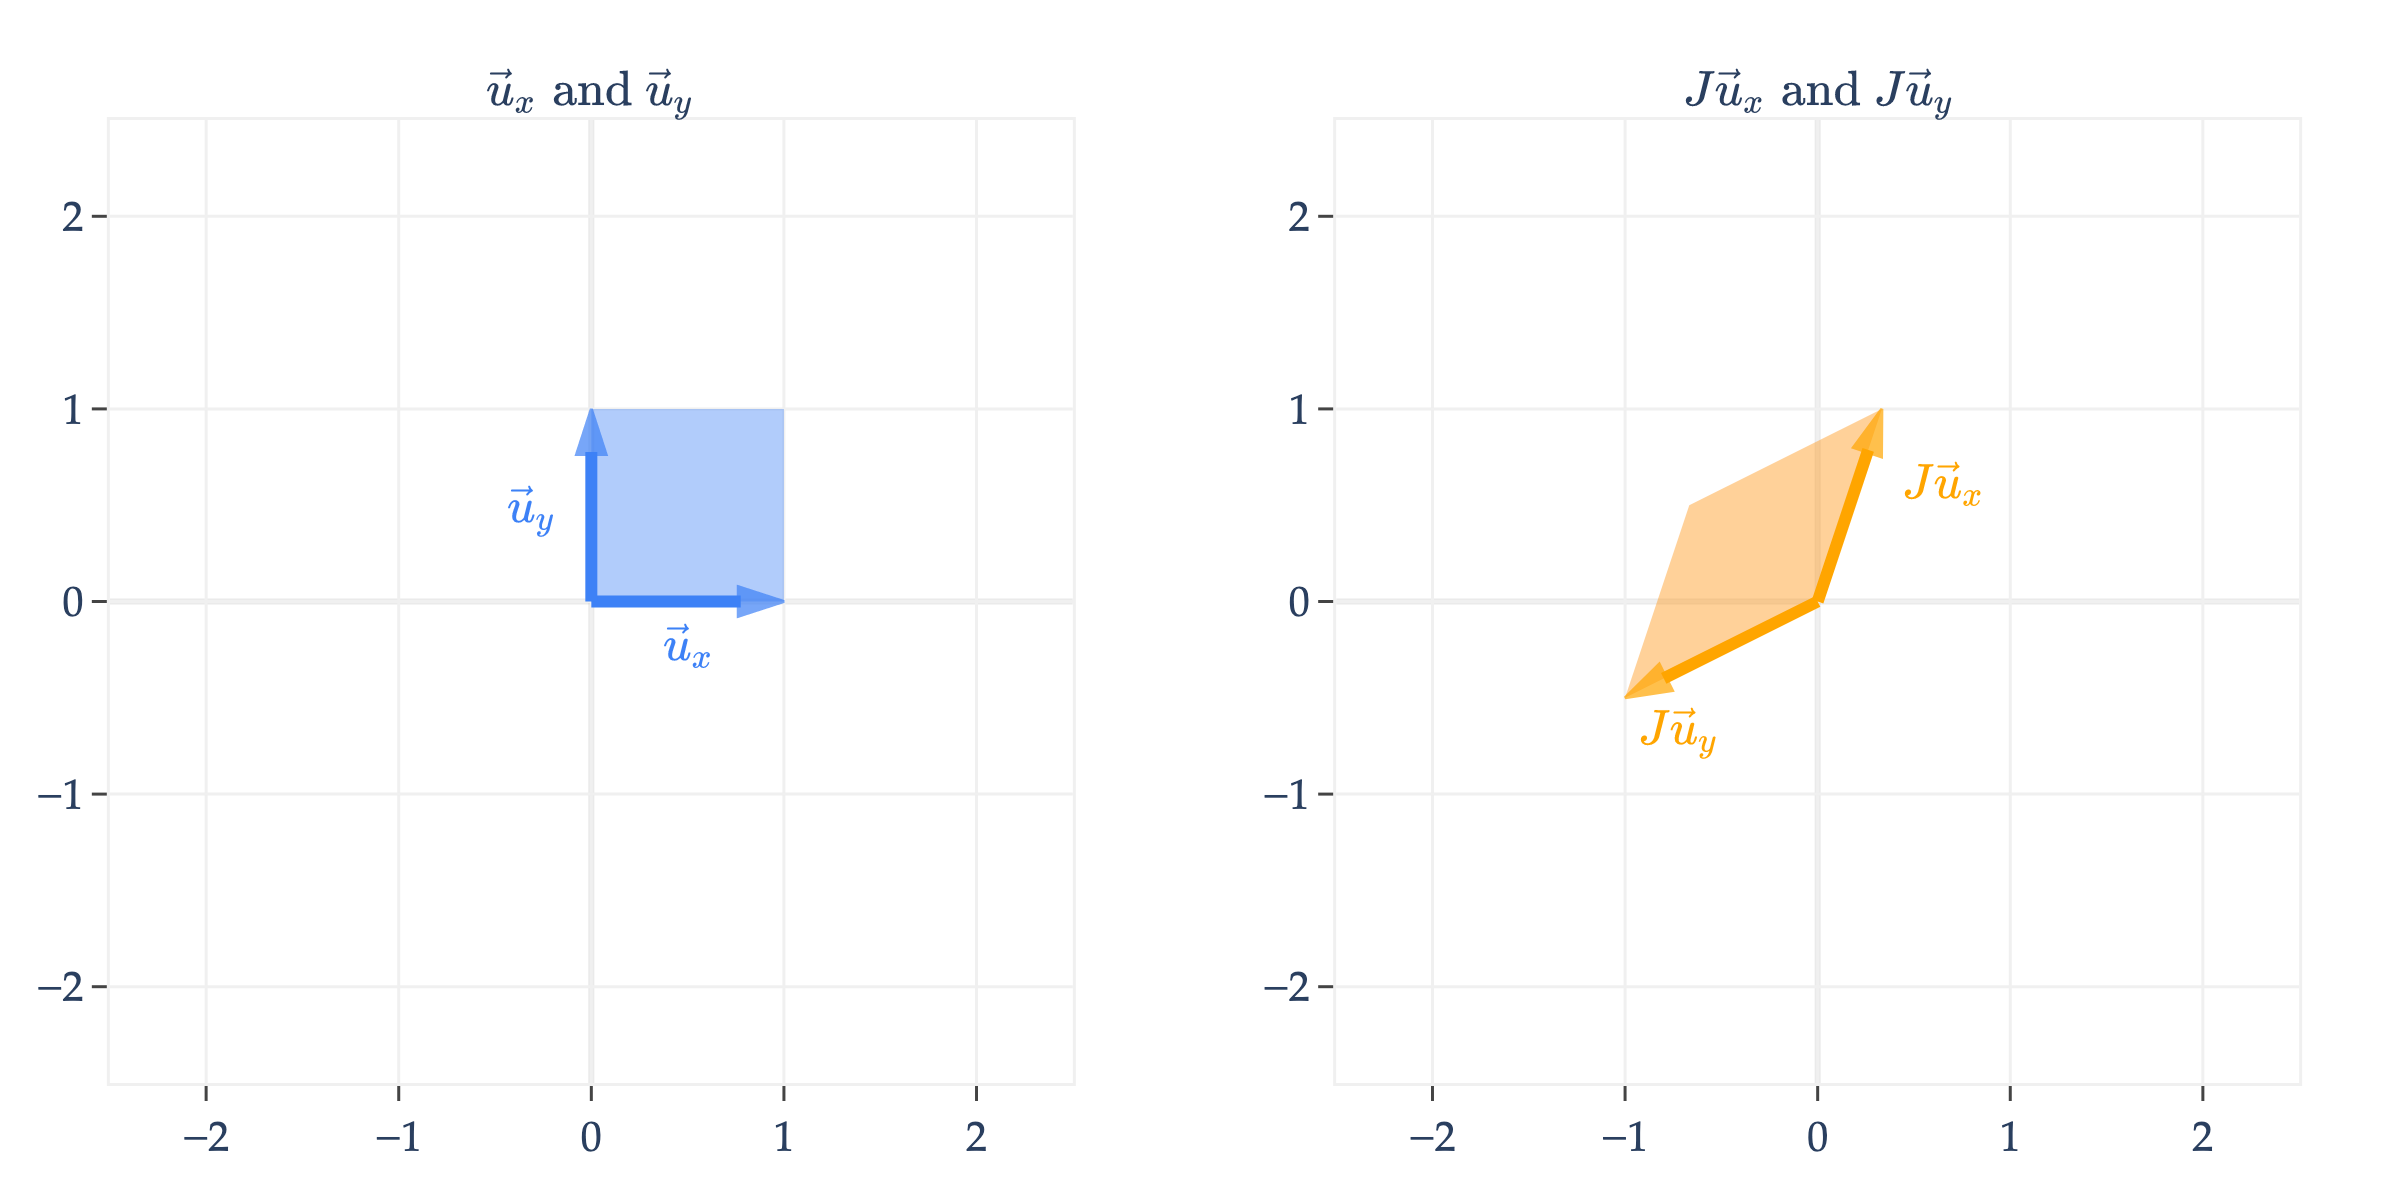

In [236]:
J = np.array([[1 / 3, -1], [1, -1 / 2]])
plot_unit_square_and_transform(J, name="J", vdeltay=0.45, vdeltax=-0.5)

Note that a determinant **can be negative**! So, to be precise, $|\text{det}(A)|$ describes the $n$-dimensional volume of the object formed by transforming the unit $n$-cube by $A$.

The sign of the determinant depends on the order of the columns of the matrix. For example, swap the columns of $J$ and its determinant would be $-\frac{5}{6}$. (If $A \vec u_x$ is "to the right" of $A \vec u_y$, the determinant is positive, like with the standard basis vectors; if $A \vec u_x$ is "to the left" of $A \vec u_y$, the determinant is negative.)

The determinant of an $n \times n$ matrix can be expressed recursively using a weighted sum of determinants of smaller $n-1 \times n-1$ matrices, called minors. For example, if $A$ is the $3 \times 3$ matrix

$$A = \begin{bmatrix} {\color{3d81f6} a} & {\color{3d81f6} b} & {\color{3d81f6} c} \\ {\color{orange} d} & {\color{d81a60}e } & {\color{004d40}f } \\ {\color{orange} g} & {\color{d81a60}h } & {\color{004d40}i } \end{bmatrix}$$

then $\text{det}(A)$ is

$$\text{det}(A) = {\color{3d81f6} a} \begin{vmatrix} {\color{d81a60}e } & {\color{004d40}f } \\ {\color{d81a60}h } & {\color{004d40}i } \end{vmatrix} - {\color{3d81f6} b} \begin{vmatrix} {\color{orange} d} & {\color{004d40}f } \\ {\color{orange} g} & {\color{004d40}i } \end{vmatrix} + {\color{3d81f6} c} \begin{vmatrix} {\color{orange} d} & {\color{d81a60}e } \\ {\color{orange} g} & {\color{d81a60}h } \end{vmatrix}$$

The matrix $\begin{bmatrix} e & f \\ h & i \end{bmatrix}$ is a minor of $A$; it's formed by deleting the first row and first column of $A$. Note the alternating signs in the formula. This formula generalizes to $n \times n$ matrices, but is not practical for anything larger than $3 \times 3$. (What is the runtime of this algorithm?)

The computation of the determinant is not super important. **The big idea is that the determinant of $A$ is a single number that tells us whether $A$'s transformation "loses a dimension" or not.**

Some useful properties of the determinant are that, for any $n \times n$ matrices $A$ and $B$,

1. $\text{det}(A) = \text{det}(A^T)$
1. $\text{det}(AB) = \text{det}(A) \text{det}(B)$
1. $\text{det}(cA) = c^n \text{det}(A)$ (notice the exponent!)
1. If $B$ results from swapping two of $A$'s columns (or rows), then $$\text{det}(B) = -\text{det}(A)$$

The proofs of these properties are beyond the scope of our course. But, it's worthwhile to think about what they mean in English in the context of linear transformations.

1. $\text{det}(A) = \text{det}(A^T)$ implies that the rows of $A$ (which are the columns of $A^T$) create the same "volume" as the columns of $A$.
1. $\text{det}(AB) = \text{det}(A) \text{det}(B)$ matches our intuition that linear transformations can be composed. $AB \vec x$ is the result of applying $B$ to $\vec x$, then $A$ to the result.
1. $\text{det}(cA) = c^n \text{det}(A)$ multiplies each column of $A$ by $c$, and so the volume of the resulting object is scaled by $c \times c \times \cdots \times c = c^n$.
1. If $B$ results from swapping two of $A$'s columns (or rows), then $\text{det}(B) = -\text{det}(A)$ reflects that swapping two columns reverses the orientation of the transformation, flipping the signed volume from positive to negative (or vice versa) while preserving its magnitude.

[**This YouTube playlist**](https://www.youtube.com/playlist?list=PLEFTQpsm47qSEmQRCtKfN7dj2qg9xzgai) contains walkthrough videos of the following activity, which has 5 subparts. The first video, embedded below, contains a brief overview of determinants, summarizing the content above.

<iframe width="560" height="315" src="https://www.youtube.com/embed/VsAhcZxnS0s?si=OyN5vkZcRW6LC9yO" title="YouTube video player" frameborder="0" allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share" referrerpolicy="strict-origin-when-cross-origin" allowfullscreen></iframe>

:::{tip} Activity 2
:class: dropdown

**Activity 2.1**
 
Find the determinant of the following matrices:

1. $A = \begin{bmatrix} 1 & 2 \\ 3 & 4 \end{bmatrix}$
1. $A = \begin{bmatrix} 1 & 3 \\ 2 & 4 \end{bmatrix}$
1. $A = \begin{bmatrix} 2 & 1 \\ 4 & 3 \end{bmatrix}$
1. $A = \begin{bmatrix} 4 & 2 & 0 \\ 3 & 1 & 1 \\ -6 & 2 & 5 \end{bmatrix}$

<details><summary>Walkthrough video</summary>

<iframe width="560" height="315" src="https://www.youtube.com/embed/fdd6d5Rfbzo?si=OyN5vkZcRW6LC9yO" title="YouTube video player" frameborder="0" allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share" referrerpolicy="strict-origin-when-cross-origin" allowfullscreen></iframe>

</details>

**Activity 2.2**

Suppose $A$ and $B$ are both $n \times n$ matrices. Is $\text{det}(A + B) = \text{det}(A) + \text{det}(B)$ in general?

<details><summary>Walkthrough video</summary>

<iframe width="560" height="315" src="https://www.youtube.com/embed/EQugtzjD5bg?si=OyN5vkZcRW6LC9yO" title="YouTube video player" frameborder="0" allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share" referrerpolicy="strict-origin-when-cross-origin" allowfullscreen></iframe>

</details>

**Activity 2.3**

Suppose we multiply $A$'s 2nd column by 3. What happens to $\text{det}(A)$?

<details><summary>Walkthrough video</summary>

<iframe width="560" height="315" src="https://www.youtube.com/embed/gk93HaAAsss?si=OyN5vkZcRW6LC9yO" title="YouTube video player" frameborder="0" allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share" referrerpolicy="strict-origin-when-cross-origin" allowfullscreen></iframe>

</details>

**Activity 2.4**

If $A$'s columns are linearly dependent, then find $\text{det}(AB)$.

<details><summary>Walkthrough video</summary>

<iframe width="560" height="315" src="https://www.youtube.com/embed/Q7aNw-fjGiM" title="YouTube video player" frameborder="0" allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share" referrerpolicy="strict-origin-when-cross-origin" allowfullscreen></iframe>

</details>

**Activity 2.5**

1. Find the determinant of $R(\theta) = \begin{bmatrix} \cos \theta & -\sin \theta \\ \sin \theta & \cos \theta \end{bmatrix}$ (Hint: The answer does not depend on $\theta$!).
1. $R(\theta)$ is a $2 \times 2$ orthogonal matrix. If $Q$ is an $n \times n$ orthogonal matrix, then what is $\text{det}(Q)$?

<details><summary>Walkthrough video</summary>

<iframe width="560" height="315" src="https://www.youtube.com/embed/x9d_WoCchy8?si=OyN5vkZcRW6LC9yO" title="YouTube video player" frameborder="0" allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share" referrerpolicy="strict-origin-when-cross-origin" allowfullscreen></iframe>

</details>

:::

Now that we have a better understanding of the linear transformations that are implicitly defined by square matrices, we can return to the question of inverses, when they exist, and how to find them.